In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

from graph_functions import *

In [2]:
def partitions(n, k, p=1):
	if n < p: return
	elif k == 0:
		if n == 0: yield []
	elif k == 1:
		if n != 0: yield [n]
	else:
		for r in partitions(n-p, k-1, p):
			yield [p] + r
		yield from partitions(n, k, p + 1)


def infect_cycle(n, k):
	for l in range(1, k + 1):
		for r in partitions(k, l):
			for p in partitions(n - k, l):
				s = []
				for b, b2 in zip(r, p):
					# s += "1" * int(b) + "0" * int(b2)
					s.extend([1] * int(b))
					s.extend([0] * int(b2))
				yield s

def generate_infection_mobious(G):
    pass

def rotate_mask(mask, shift):
    n = len(mask)
    return mask[shift:] + mask[:shift]

def generate_infection_prism(G):
    n = len(G.nodes)
    n_half = n // 2

    for k in range(2, n):
        for k1 in range(1, k):
            k2 = k - k1

            top_infections = infection_graph_permuation([0]*n_half, k1)
            bottom_infections = infection_graph_permuation([0]*n_half, k2)

            for t in top_infections:
                for b in bottom_infections:
                    for shift in range(n_half):
                        yield t + rotate_mask(b, shift)


def generate_infection_prism2(G):
    n = len(G.nodes)
    n_half = n // 2

    for k in range(2, n):
        for k1 in range(1, k):
            k2 = k - k1

            top = infection_graph_permuation([0]*n_half, k1)
            bottom = infection_graph_permuation([0]*n_half, k2)

            for t in top:
                for b in bottom:
                    yield t + b


In [3]:
graphs = generate_graphs(8)[1:]
# Using it
graph_infections = []
for G, n, a in graphs:
    unique_infections = []
    for infection_mask in generate_infection_prism(G):
        print(infection_mask)
        H = infect_graph(G, infection_mask)
        H_full, _, _ = fully_endemic(H)
        unique_infections.append((H, n, a))
        unique_infections.append((H_full, n, a))
    
    graph_infections.append(unique_infections)
    # display_graphs(unique_infections, figsize=(5, 5), show_titles=True, force_row=False)

number of graphs for n=8 : 1


In [4]:
x = generate_graphs(10)
G, _, _ = x[1]

number of graphs for n=10 : 2


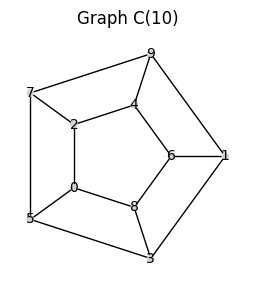

In [5]:
def split_mask(G, mask):
    n_half = len(G) // 2
    return mask[n_half:], mask[:n_half]

display_graph(G, figsize=(3,3), show_title=True, with_labels=True, pos=prism_pos(G))

In [6]:
def infect_graph_by_cycle(G_, mask):
    G = G_.copy()

    M_top, M_bottom = split_mask(G, mask)
    C_top, C_bottom = get_cycles(G)

    for m, v in zip(M_top, sorted(C_top.nodes)):
        if m:
            G.nodes[v]["infected"] = 1

    for m, v in zip(M_bottom, sorted(C_bottom.nodes)):
        if m:
            G.nodes[v]["infected"] = 1

    return G

# graph_list = []

# i = 0
# for im in generate_infection_prism2(G):
#     G_i = infect_graph_by_cycle(G, im)
#     print(im)

#     # G_i = infect_graph(G, im)
#     if i > 0 and i % 10 == 0:
#         display_graphs(graph_list, figsize=(15, 15), show_titles=True, force_row=True, with_labels=True, pos=lambda x: prism_pos(x))
#         graph_list = []
    
#     graph_list.append((G_i, len(G.nodes), 2))
#     i+=1

Number of fully endemic infections: 130

Fully endemic infection #1
Mask: [1, 0, 0, 0, 0, 0, 1, 1, 0, 0]
Steps to full infection: 3


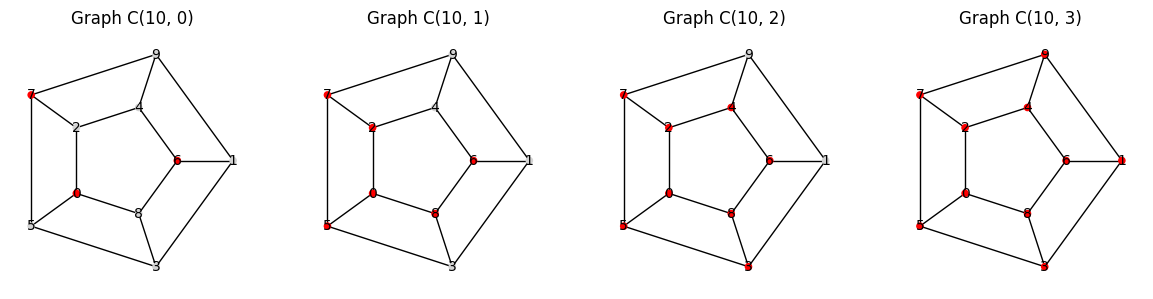


Fully endemic infection #2
Mask: [1, 0, 0, 0, 0, 0, 1, 0, 0, 1]
Steps to full infection: 3


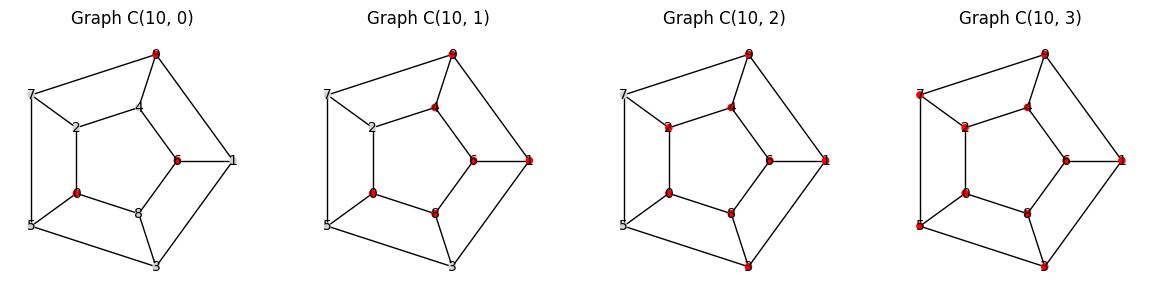


Fully endemic infection #3
Mask: [1, 1, 0, 0, 0, 0, 0, 1, 0, 0]
Steps to full infection: 3


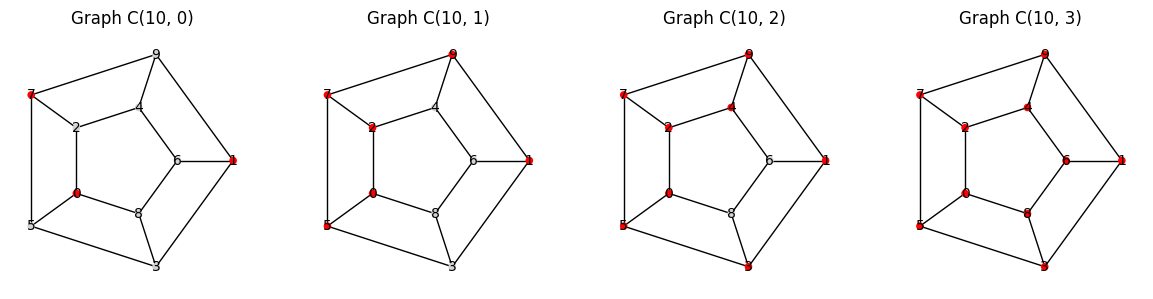


Fully endemic infection #4
Mask: [1, 0, 0, 0, 0, 1, 1, 1, 0, 0]
Steps to full infection: 3


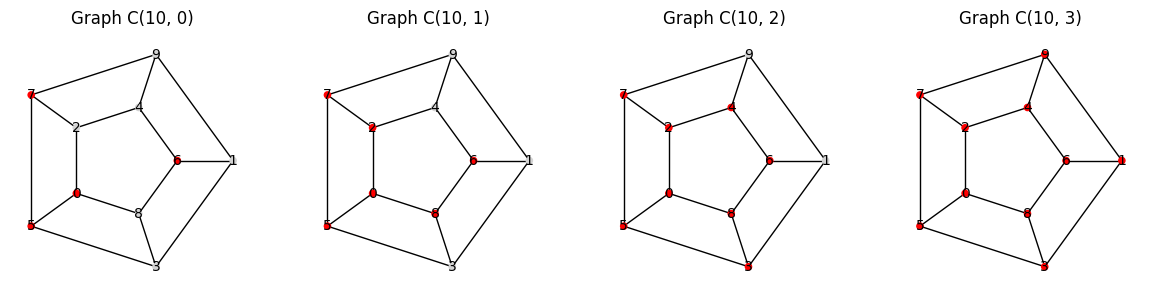


Fully endemic infection #5
Mask: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1]
Steps to full infection: 2


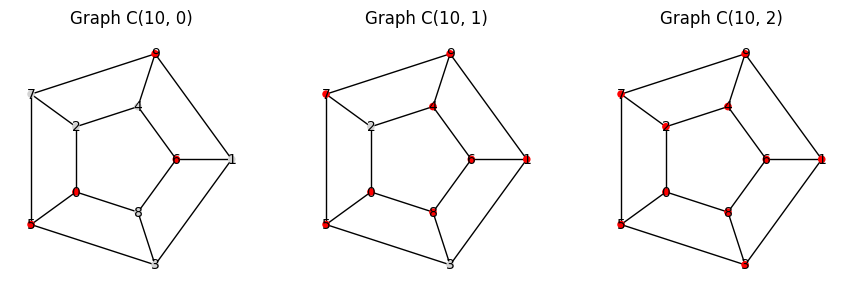


Fully endemic infection #6
Mask: [1, 0, 0, 0, 0, 1, 0, 0, 1, 1]
Steps to full infection: 3


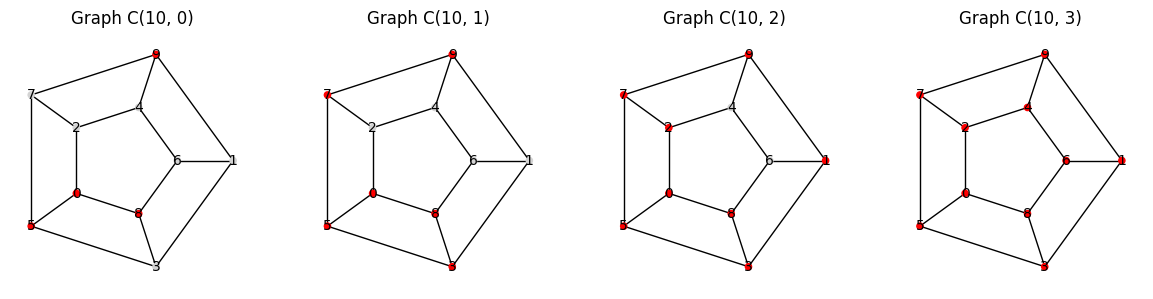


Fully endemic infection #7
Mask: [1, 0, 0, 0, 0, 0, 1, 1, 1, 0]
Steps to full infection: 3


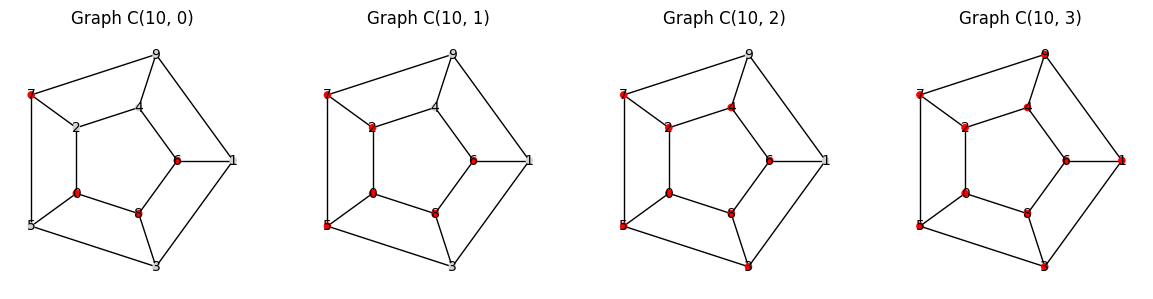


Fully endemic infection #8
Mask: [1, 0, 0, 0, 0, 0, 1, 1, 0, 1]
Steps to full infection: 2


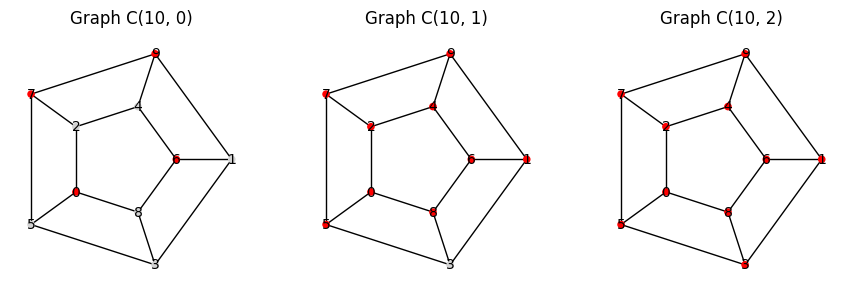


Fully endemic infection #9
Mask: [1, 0, 0, 0, 0, 0, 1, 0, 1, 1]
Steps to full infection: 3


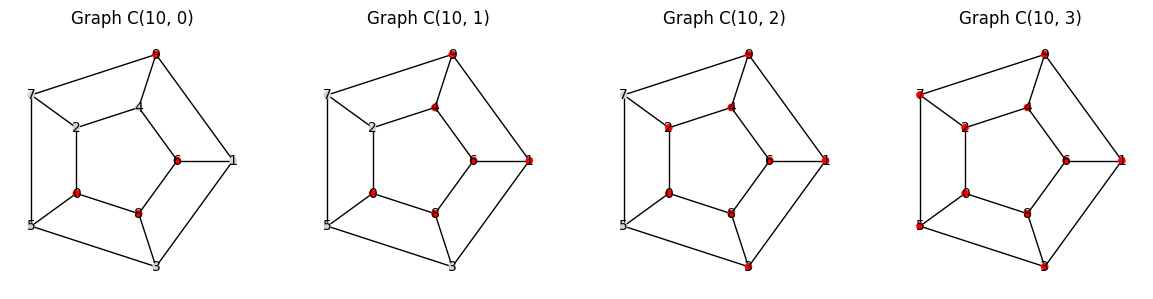


Fully endemic infection #10
Mask: [1, 0, 0, 0, 0, 0, 0, 1, 1, 1]
Steps to full infection: 3


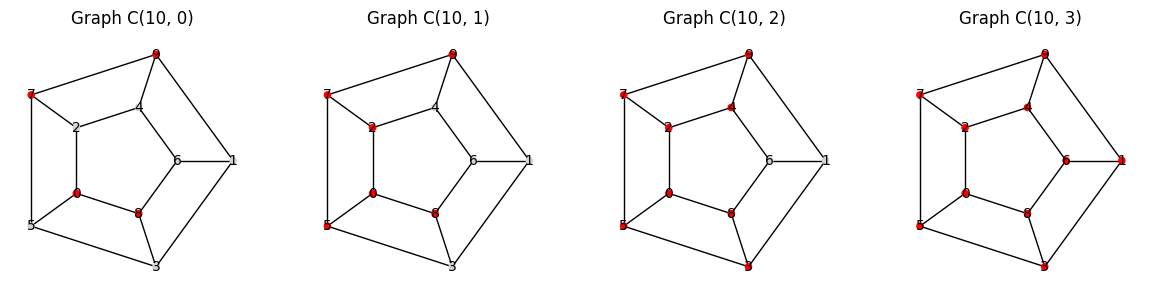


Fully endemic infection #11
Mask: [1, 1, 0, 0, 0, 1, 0, 1, 0, 0]
Steps to full infection: 3


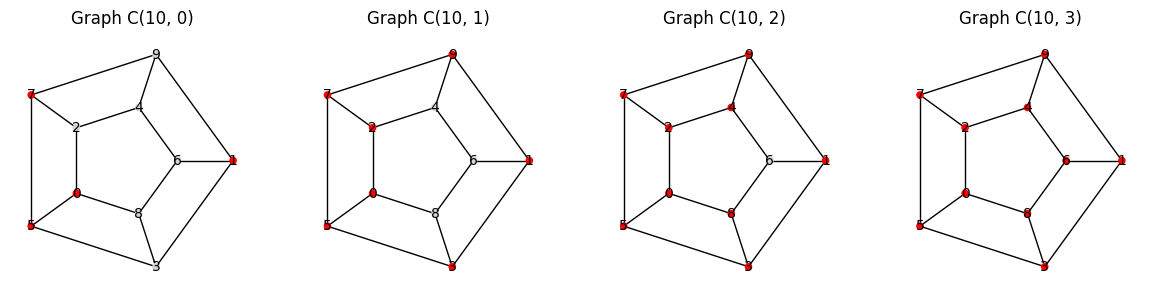


Fully endemic infection #12
Mask: [1, 1, 0, 0, 0, 1, 0, 0, 0, 1]
Steps to full infection: 3


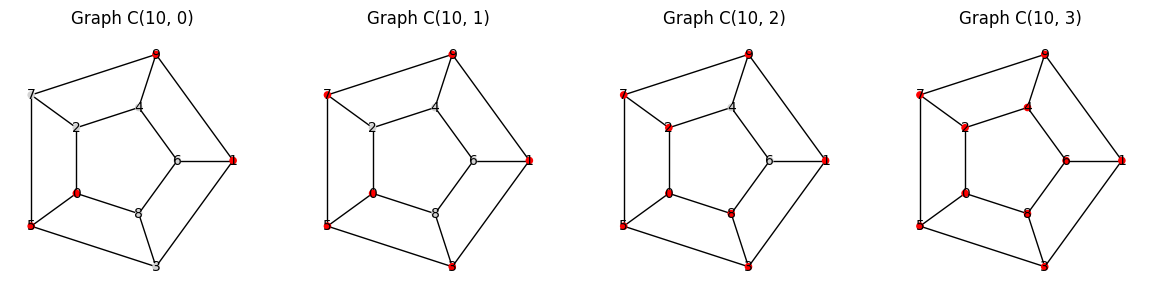


Fully endemic infection #13
Mask: [1, 1, 0, 0, 0, 0, 1, 1, 0, 0]
Steps to full infection: 2


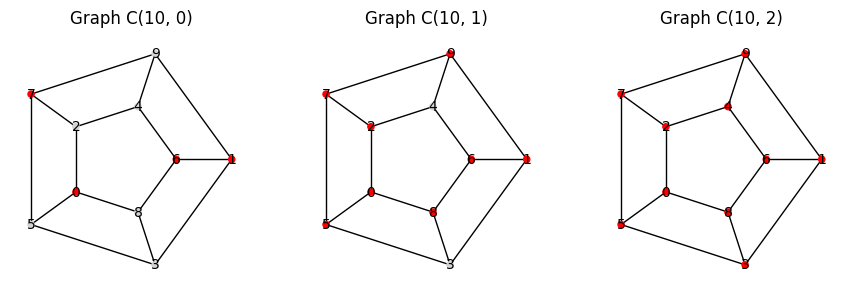


Fully endemic infection #14
Mask: [1, 1, 0, 0, 0, 0, 1, 0, 0, 1]
Steps to full infection: 3


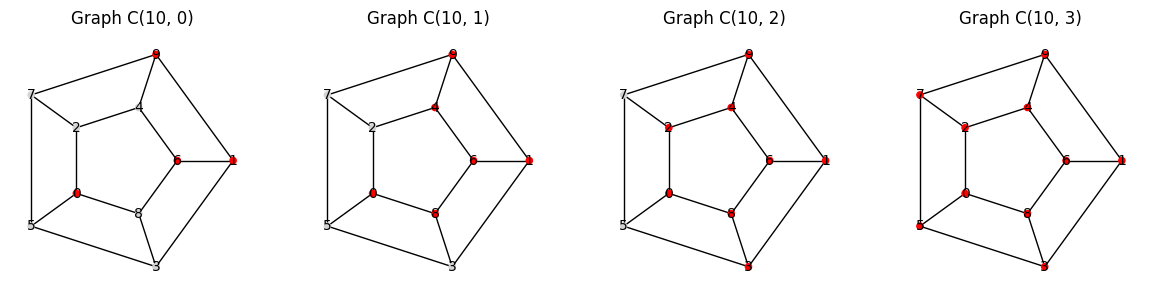


Fully endemic infection #15
Mask: [1, 1, 0, 0, 0, 0, 0, 1, 1, 0]
Steps to full infection: 2


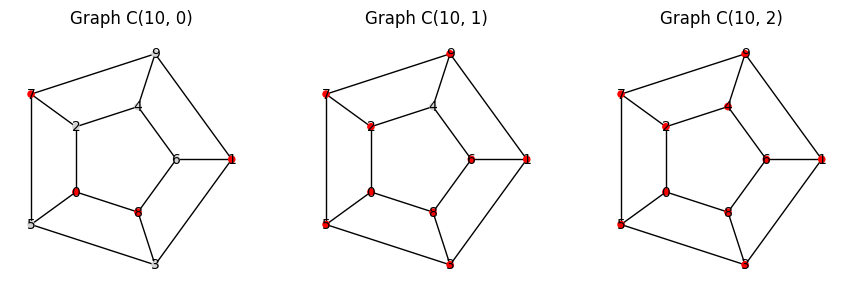


Fully endemic infection #16
Mask: [1, 1, 0, 0, 0, 0, 0, 1, 0, 1]
Steps to full infection: 3


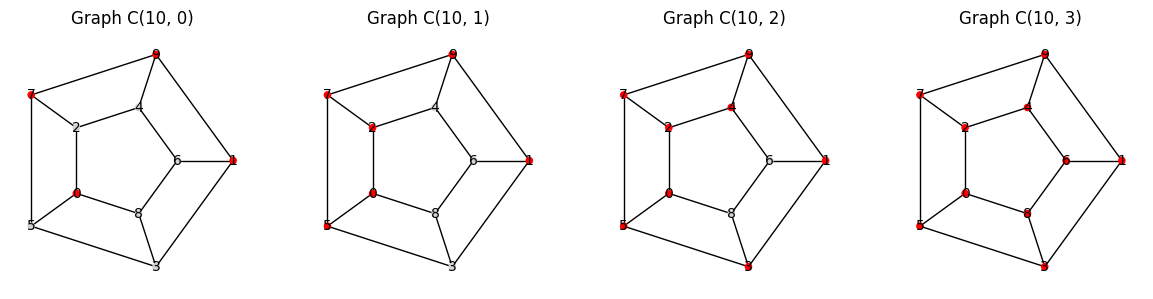


Fully endemic infection #17
Mask: [1, 1, 0, 0, 0, 0, 0, 0, 1, 1]
Steps to full infection: 3


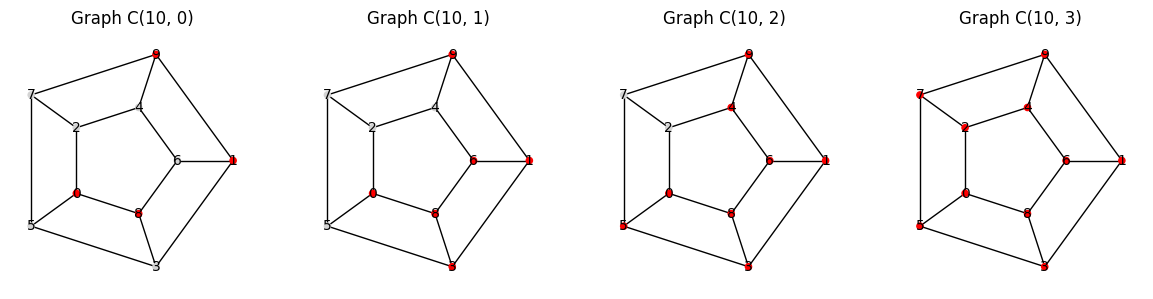


Fully endemic infection #18
Mask: [1, 1, 1, 0, 0, 1, 0, 0, 0, 0]
Steps to full infection: 3


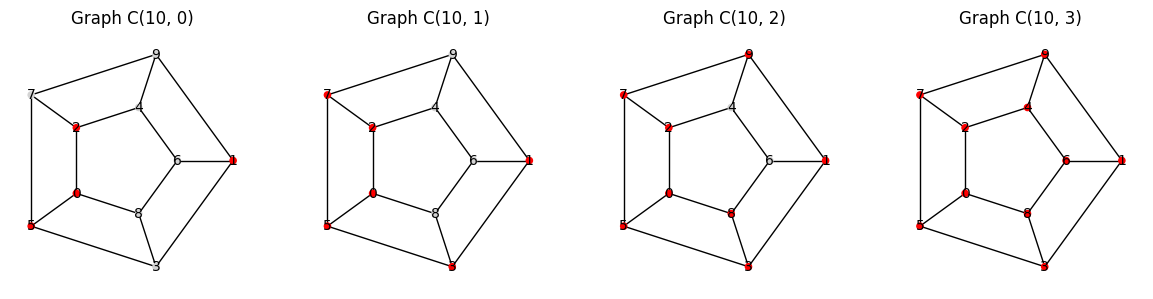


Fully endemic infection #19
Mask: [1, 1, 1, 0, 0, 0, 1, 0, 0, 0]
Steps to full infection: 3


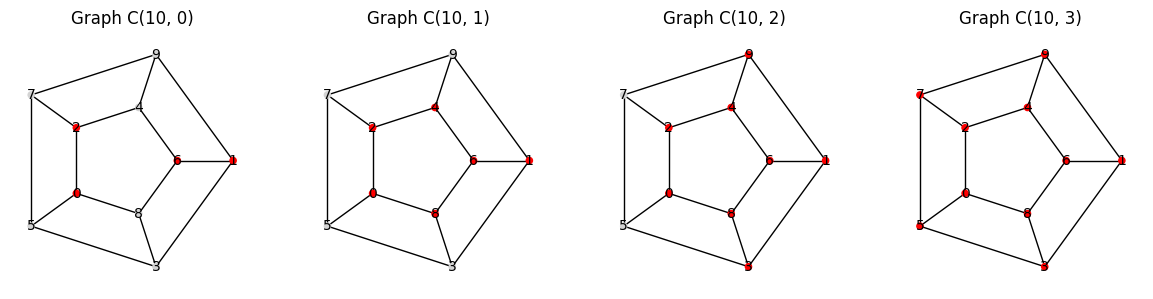


Fully endemic infection #20
Mask: [1, 1, 1, 0, 0, 0, 0, 1, 0, 0]
Steps to full infection: 3


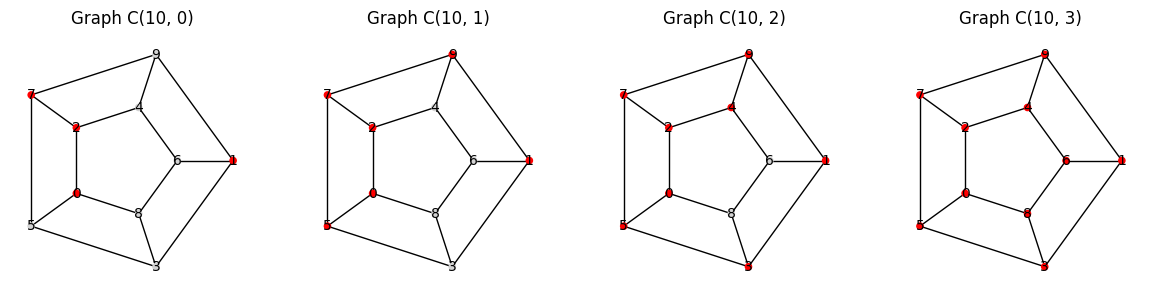


Fully endemic infection #21
Mask: [1, 1, 1, 0, 0, 0, 0, 0, 1, 0]
Steps to full infection: 3


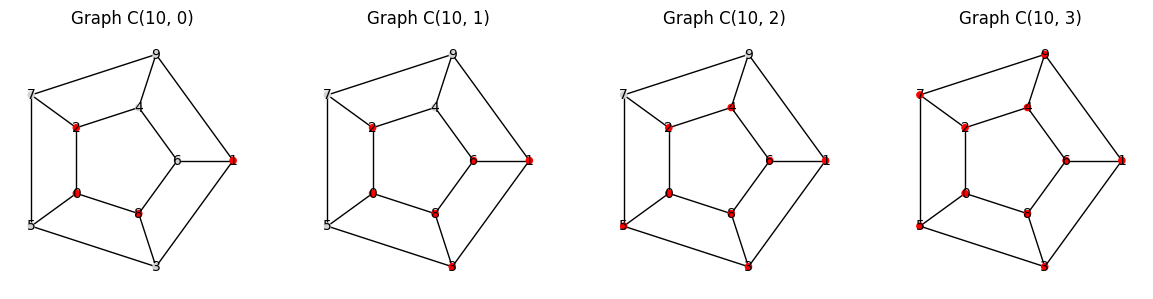


Fully endemic infection #22
Mask: [1, 1, 1, 0, 0, 0, 0, 0, 0, 1]
Steps to full infection: 3


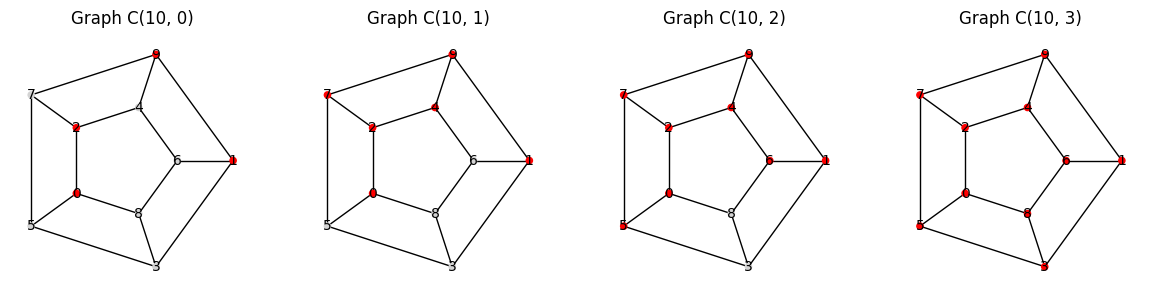


Fully endemic infection #23
Mask: [1, 0, 0, 0, 0, 1, 1, 1, 1, 0]
Steps to full infection: 3


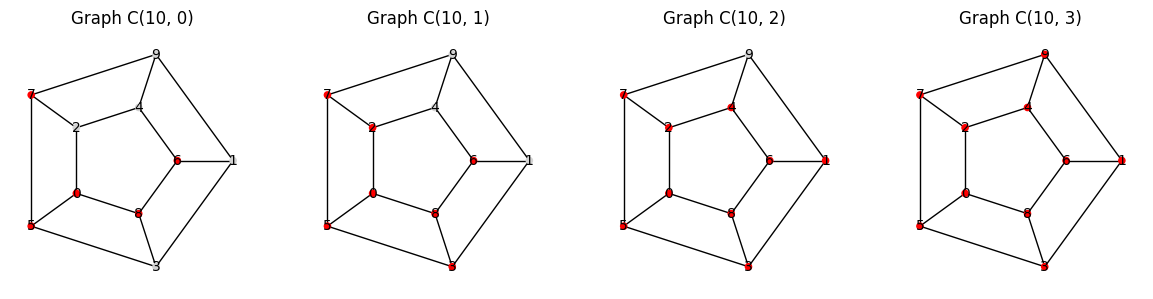


Fully endemic infection #24
Mask: [1, 0, 0, 0, 0, 1, 1, 1, 0, 1]
Steps to full infection: 2


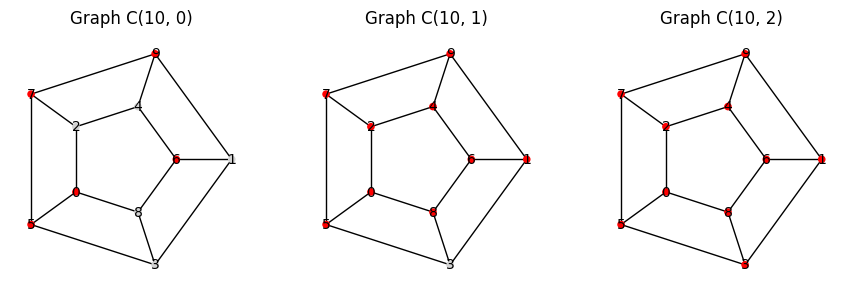


Fully endemic infection #25
Mask: [1, 0, 0, 0, 0, 1, 1, 0, 1, 1]
Steps to full infection: 2


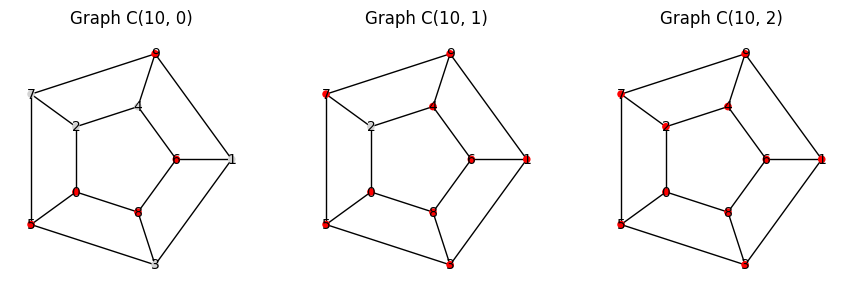


Fully endemic infection #26
Mask: [1, 0, 0, 0, 0, 1, 0, 1, 1, 1]
Steps to full infection: 3


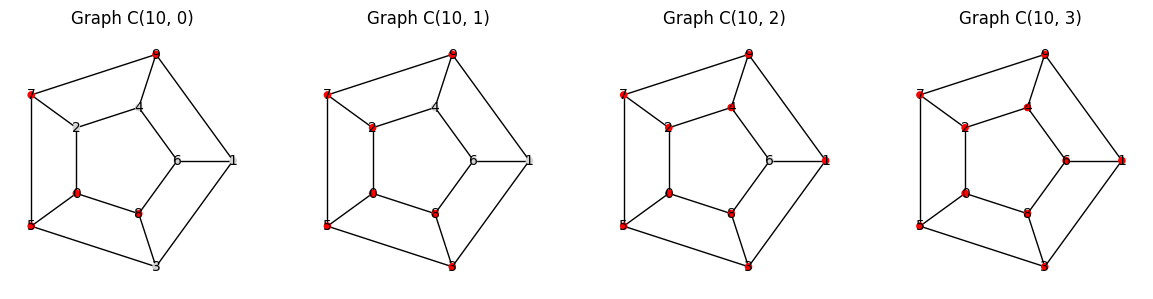


Fully endemic infection #27
Mask: [1, 0, 0, 0, 0, 0, 1, 1, 1, 1]
Steps to full infection: 2


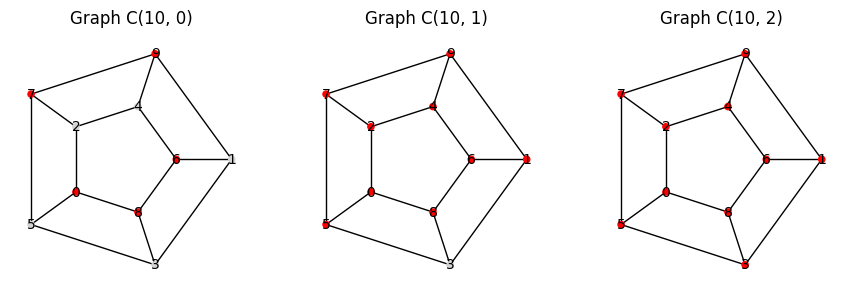


Fully endemic infection #28
Mask: [1, 1, 0, 0, 0, 1, 1, 1, 0, 0]
Steps to full infection: 2


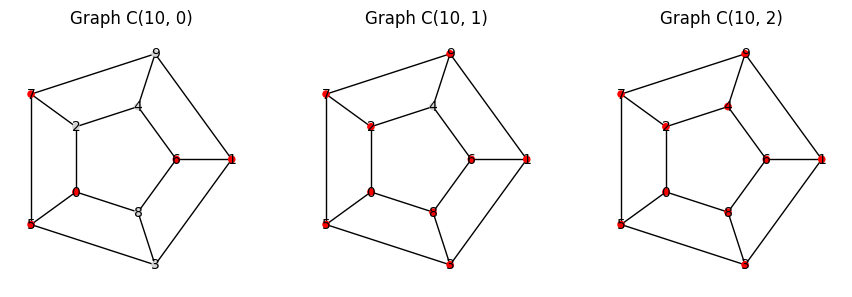


Fully endemic infection #29
Mask: [1, 1, 0, 0, 0, 1, 1, 0, 0, 1]
Steps to full infection: 2


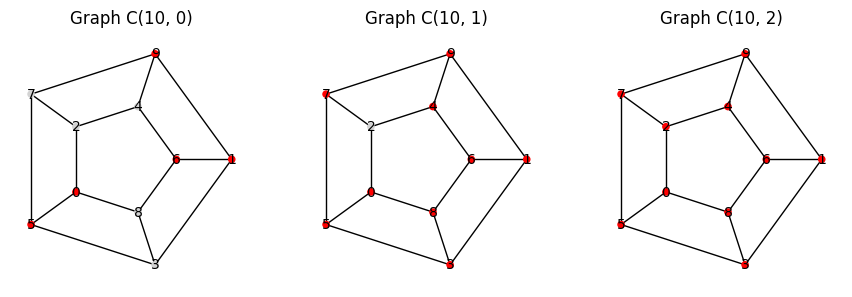


Fully endemic infection #30
Mask: [1, 1, 0, 0, 0, 1, 0, 1, 1, 0]
Steps to full infection: 2


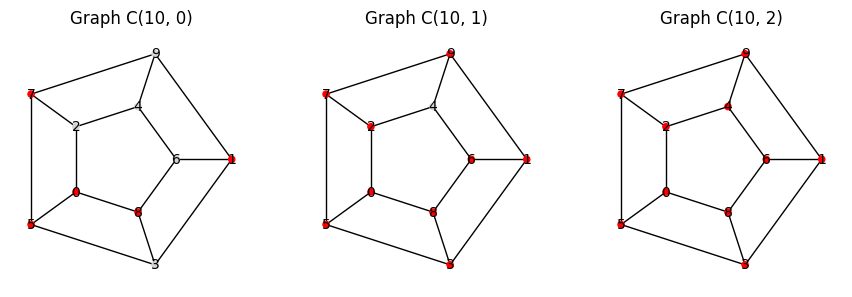


Fully endemic infection #31
Mask: [1, 1, 0, 0, 0, 1, 0, 1, 0, 1]
Steps to full infection: 3


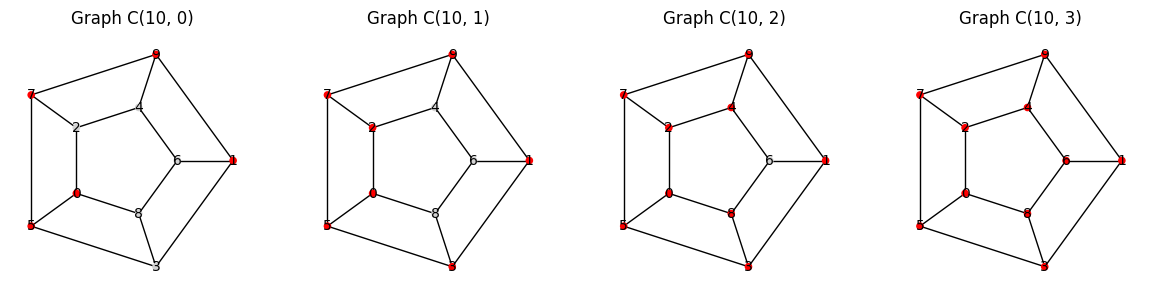


Fully endemic infection #32
Mask: [1, 1, 0, 0, 0, 1, 0, 0, 1, 1]
Steps to full infection: 2


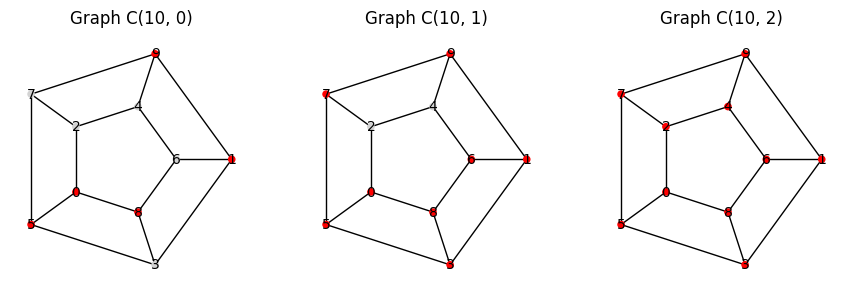


Fully endemic infection #33
Mask: [1, 1, 0, 0, 0, 0, 1, 1, 1, 0]
Steps to full infection: 2


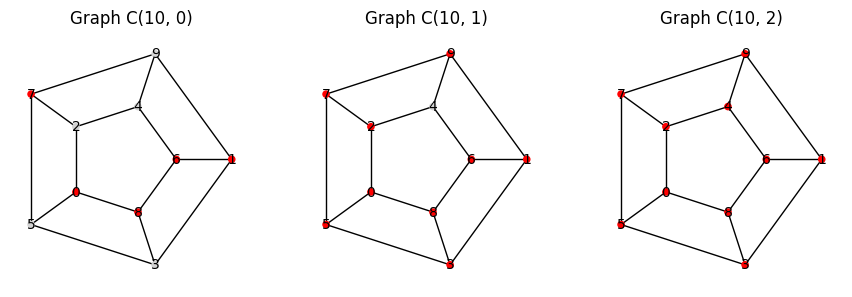


Fully endemic infection #34
Mask: [1, 1, 0, 0, 0, 0, 1, 1, 0, 1]
Steps to full infection: 2


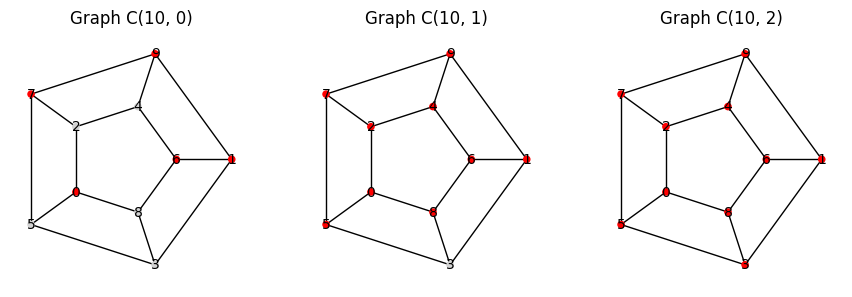


Fully endemic infection #35
Mask: [1, 1, 0, 0, 0, 0, 1, 0, 1, 1]
Steps to full infection: 3


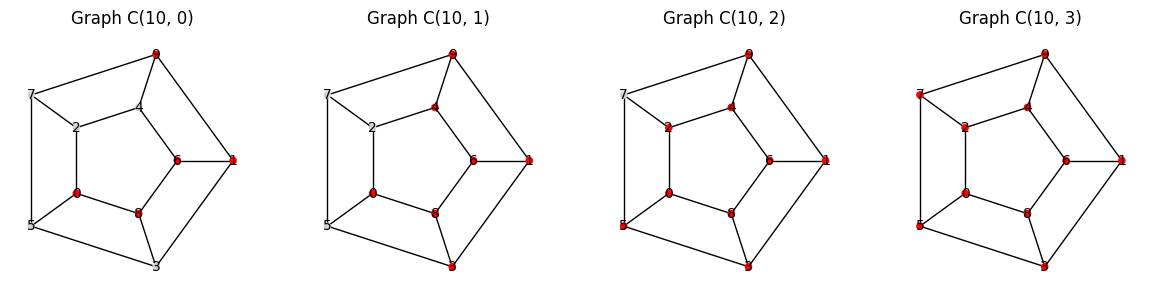


Fully endemic infection #36
Mask: [1, 1, 0, 0, 0, 0, 0, 1, 1, 1]
Steps to full infection: 2


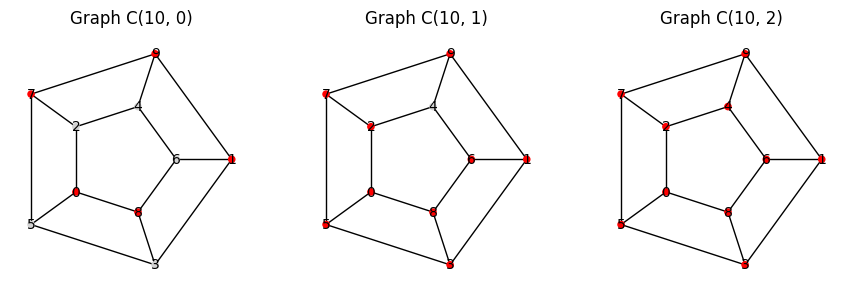


Fully endemic infection #37
Mask: [1, 1, 1, 0, 0, 1, 1, 0, 0, 0]
Steps to full infection: 2


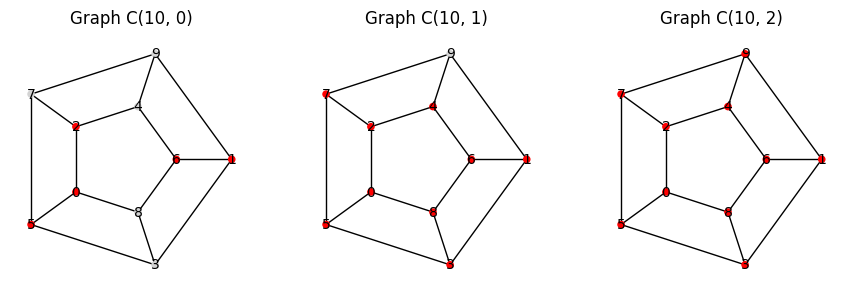


Fully endemic infection #38
Mask: [1, 1, 1, 0, 0, 1, 0, 1, 0, 0]
Steps to full infection: 3


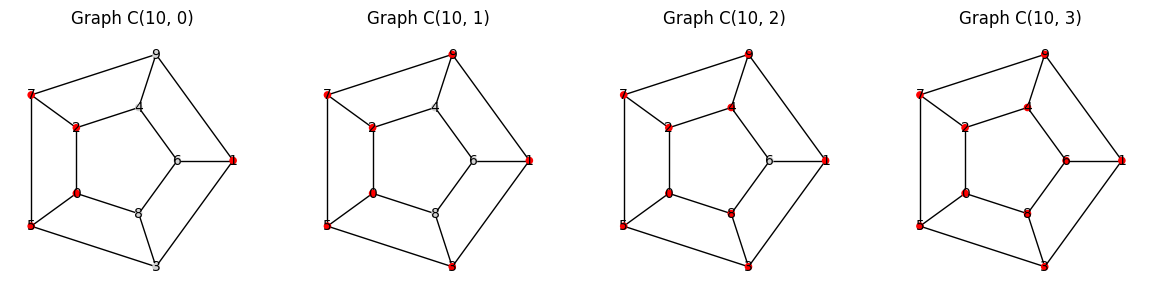


Fully endemic infection #39
Mask: [1, 1, 1, 0, 0, 1, 0, 0, 1, 0]
Steps to full infection: 2


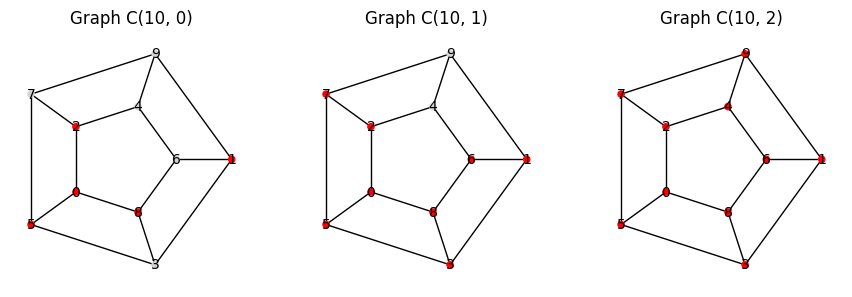


Fully endemic infection #40
Mask: [1, 1, 1, 0, 0, 1, 0, 0, 0, 1]
Steps to full infection: 2


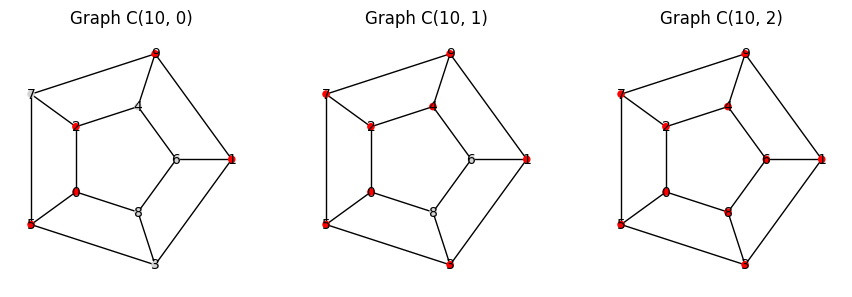


Fully endemic infection #41
Mask: [1, 1, 1, 0, 0, 0, 1, 1, 0, 0]
Steps to full infection: 2


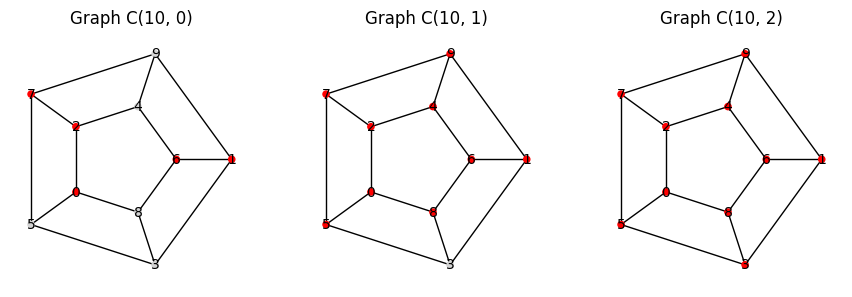


Fully endemic infection #42
Mask: [1, 1, 1, 0, 0, 0, 1, 0, 1, 0]
Steps to full infection: 3


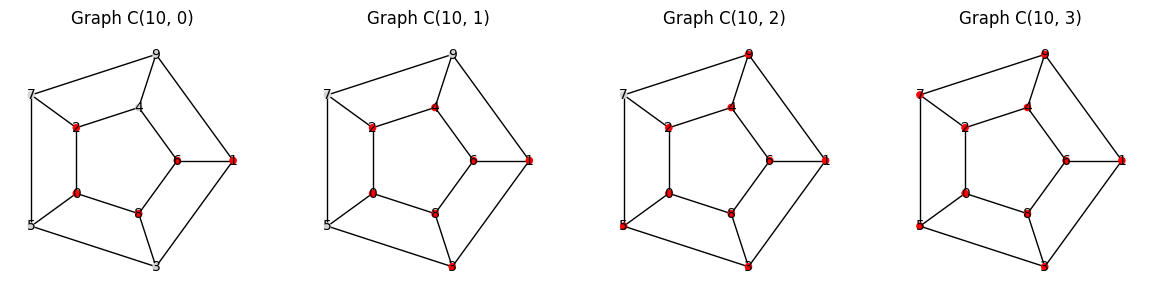


Fully endemic infection #43
Mask: [1, 1, 1, 0, 0, 0, 1, 0, 0, 1]
Steps to full infection: 2


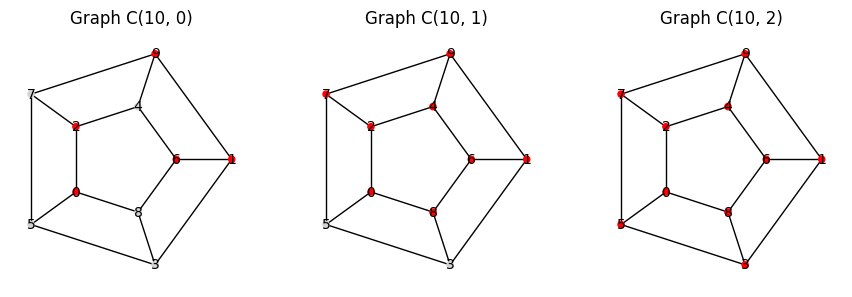


Fully endemic infection #44
Mask: [1, 1, 1, 0, 0, 0, 0, 1, 1, 0]
Steps to full infection: 2


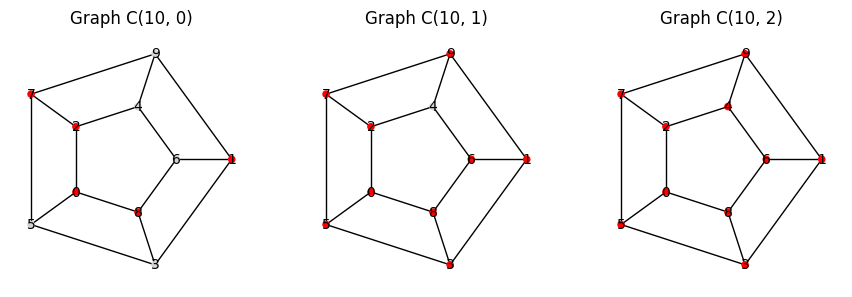


Fully endemic infection #45
Mask: [1, 1, 1, 0, 0, 0, 0, 1, 0, 1]
Steps to full infection: 3


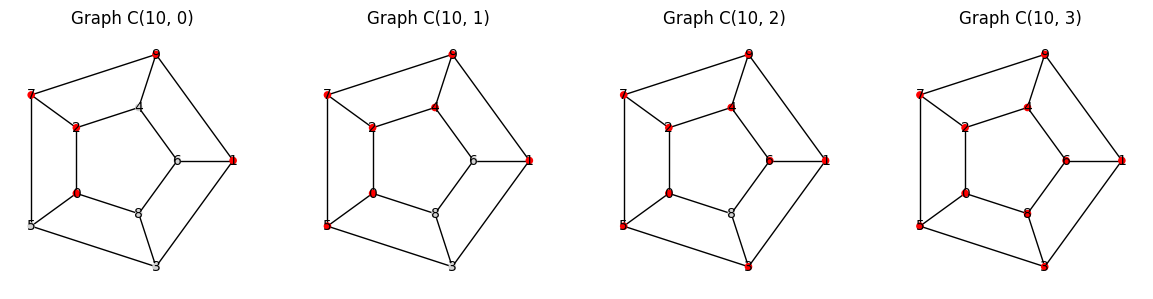


Fully endemic infection #46
Mask: [1, 1, 1, 0, 0, 0, 0, 0, 1, 1]
Steps to full infection: 2


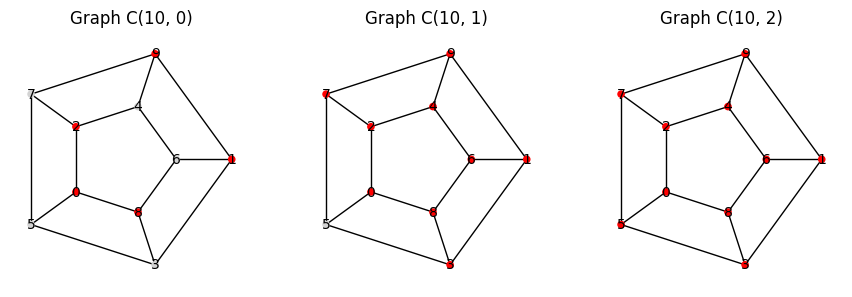


Fully endemic infection #47
Mask: [1, 1, 1, 1, 0, 1, 0, 0, 0, 0]
Steps to full infection: 3


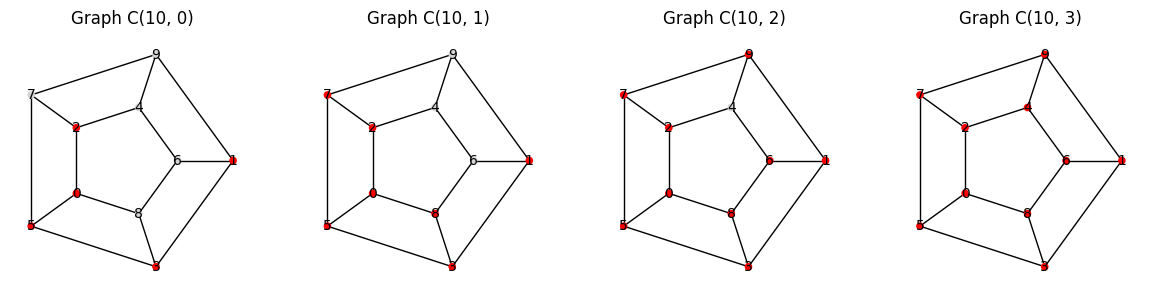


Fully endemic infection #48
Mask: [1, 1, 1, 1, 0, 0, 1, 0, 0, 0]
Steps to full infection: 2


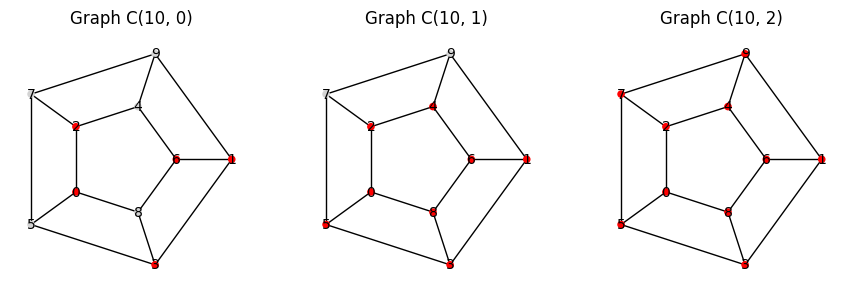


Fully endemic infection #49
Mask: [1, 1, 1, 1, 0, 0, 0, 1, 0, 0]
Steps to full infection: 2


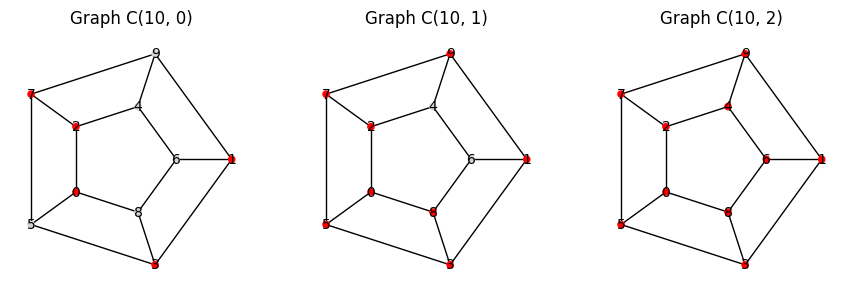


Fully endemic infection #50
Mask: [1, 1, 1, 1, 0, 0, 0, 0, 1, 0]
Steps to full infection: 3


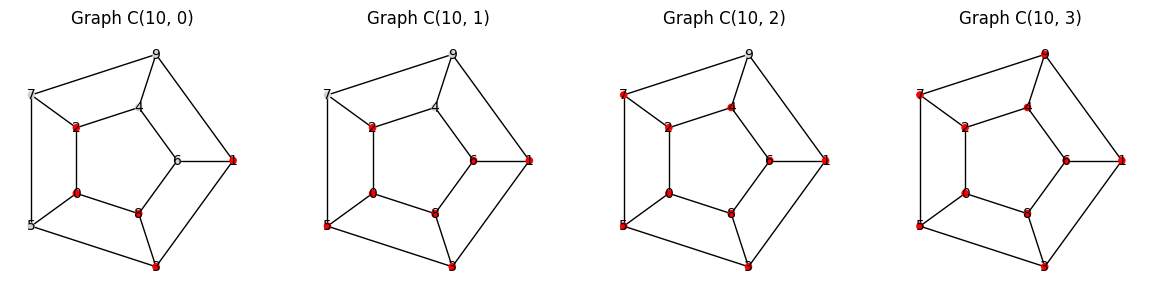


Fully endemic infection #51
Mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 1]
Steps to full infection: 2


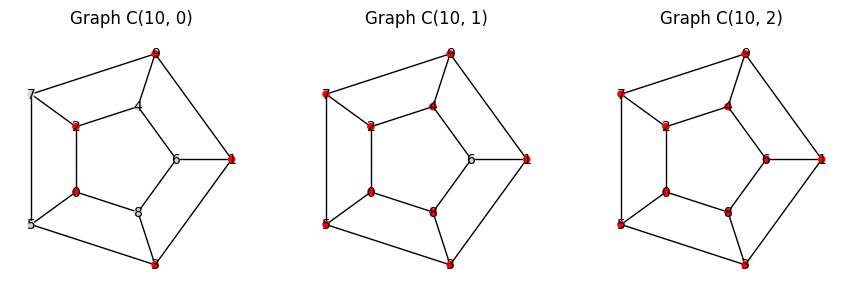


Fully endemic infection #52
Mask: [1, 0, 0, 0, 0, 1, 1, 1, 1, 1]
Steps to full infection: 1


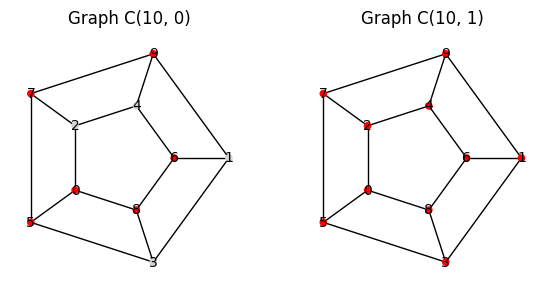


Fully endemic infection #53
Mask: [1, 1, 0, 0, 0, 1, 1, 1, 1, 0]
Steps to full infection: 2


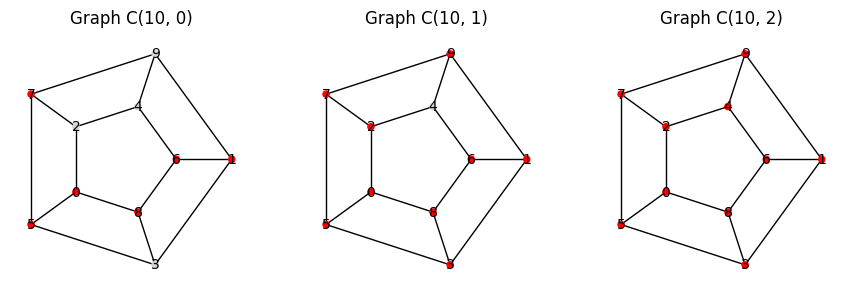


Fully endemic infection #54
Mask: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1]
Steps to full infection: 1


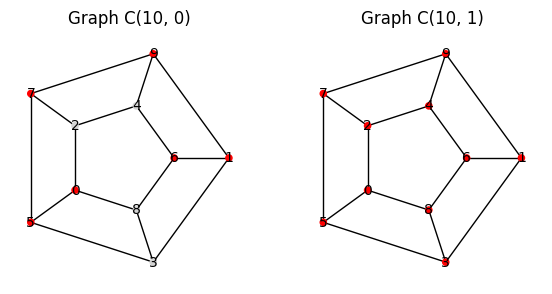


Fully endemic infection #55
Mask: [1, 1, 0, 0, 0, 1, 1, 0, 1, 1]
Steps to full infection: 2


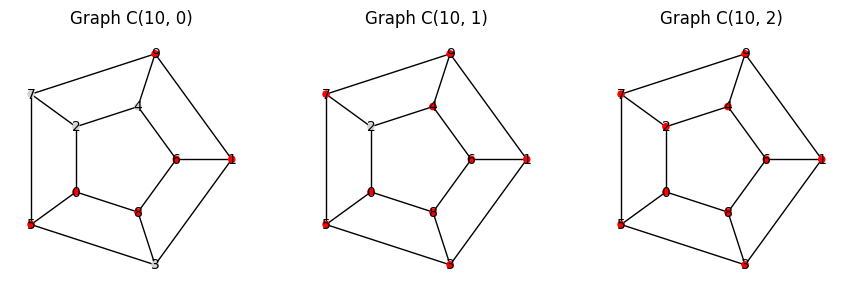


Fully endemic infection #56
Mask: [1, 1, 0, 0, 0, 1, 0, 1, 1, 1]
Steps to full infection: 2


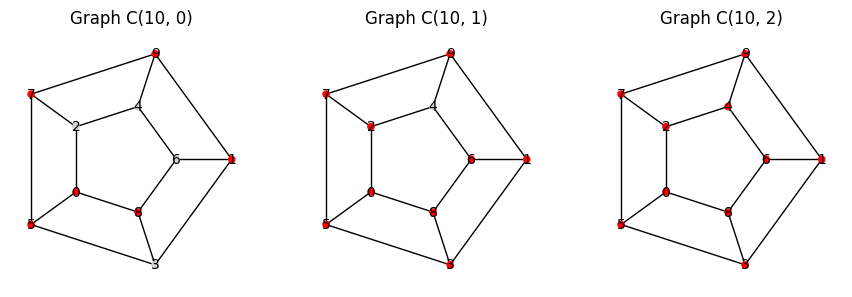


Fully endemic infection #57
Mask: [1, 1, 0, 0, 0, 0, 1, 1, 1, 1]
Steps to full infection: 1


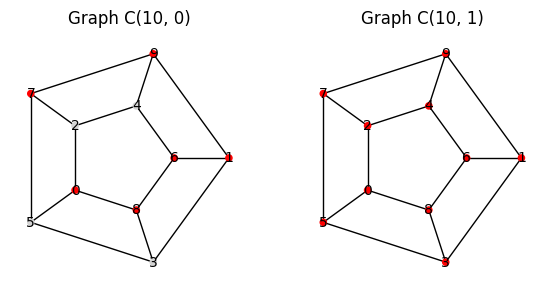


Fully endemic infection #58
Mask: [1, 1, 1, 0, 0, 1, 1, 1, 0, 0]
Steps to full infection: 1


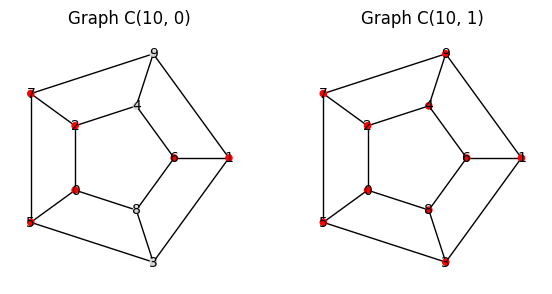


Fully endemic infection #59
Mask: [1, 1, 1, 0, 0, 1, 1, 0, 1, 0]
Steps to full infection: 2


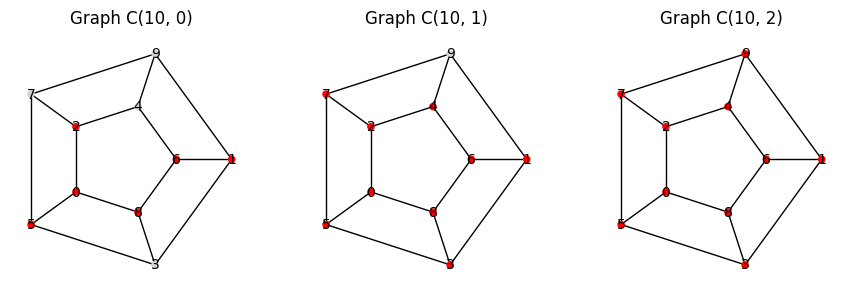


Fully endemic infection #60
Mask: [1, 1, 1, 0, 0, 1, 1, 0, 0, 1]
Steps to full infection: 1


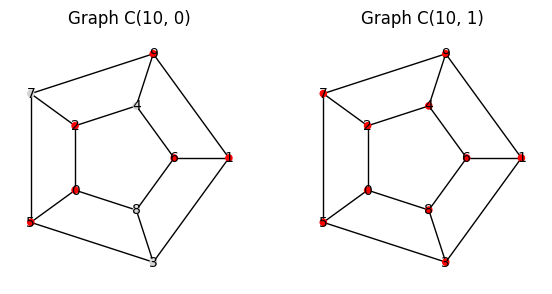


Fully endemic infection #61
Mask: [1, 1, 1, 0, 0, 1, 0, 1, 1, 0]
Steps to full infection: 2


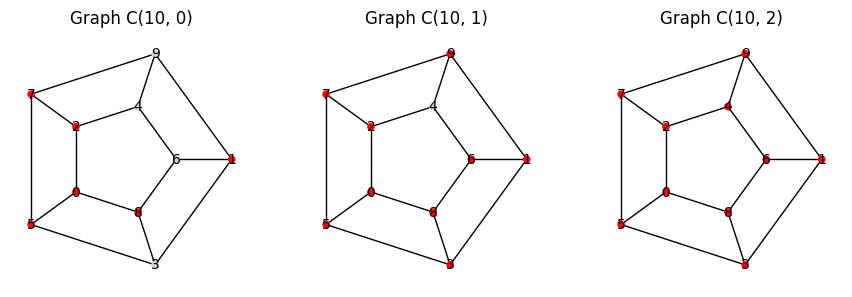


Fully endemic infection #62
Mask: [1, 1, 1, 0, 0, 1, 0, 1, 0, 1]
Steps to full infection: 2


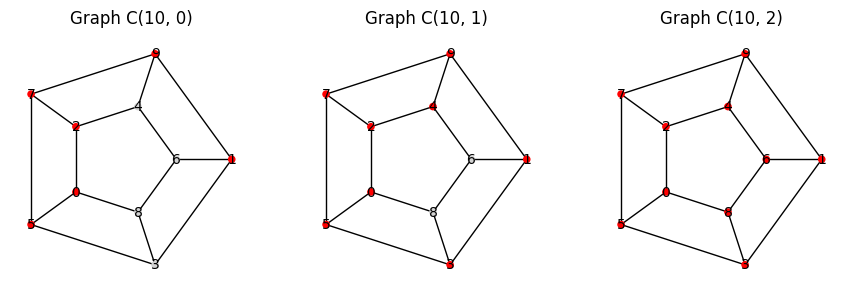


Fully endemic infection #63
Mask: [1, 1, 1, 0, 0, 1, 0, 0, 1, 1]
Steps to full infection: 1


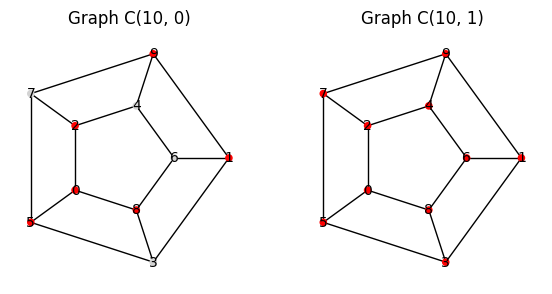


Fully endemic infection #64
Mask: [1, 1, 1, 0, 0, 0, 1, 1, 1, 0]
Steps to full infection: 1


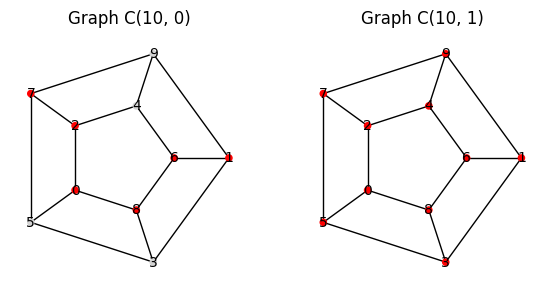


Fully endemic infection #65
Mask: [1, 1, 1, 0, 0, 0, 1, 1, 0, 1]
Steps to full infection: 2


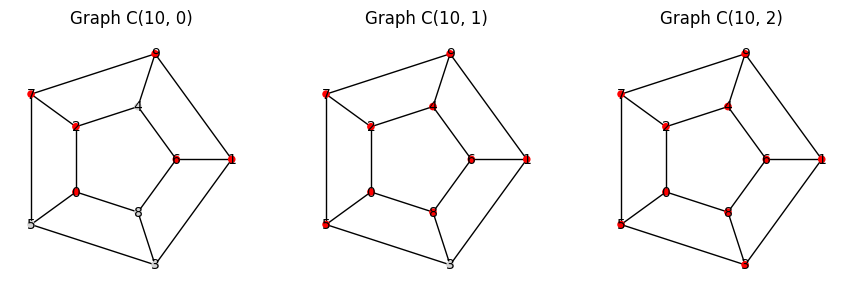


Fully endemic infection #66
Mask: [1, 1, 1, 0, 0, 0, 1, 0, 1, 1]
Steps to full infection: 2


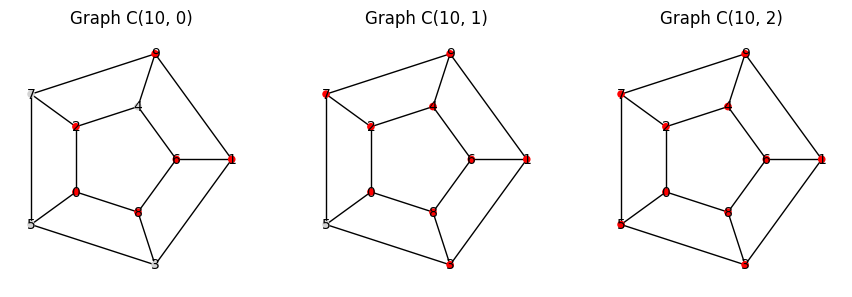


Fully endemic infection #67
Mask: [1, 1, 1, 0, 0, 0, 0, 1, 1, 1]
Steps to full infection: 1


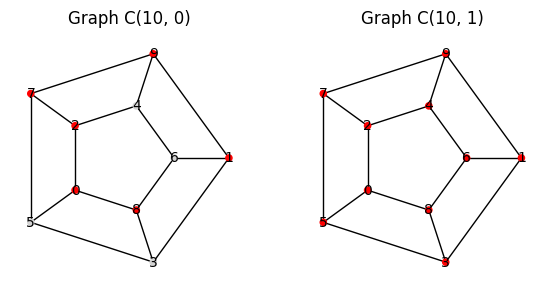


Fully endemic infection #68
Mask: [1, 1, 1, 1, 0, 1, 1, 0, 0, 0]
Steps to full infection: 2


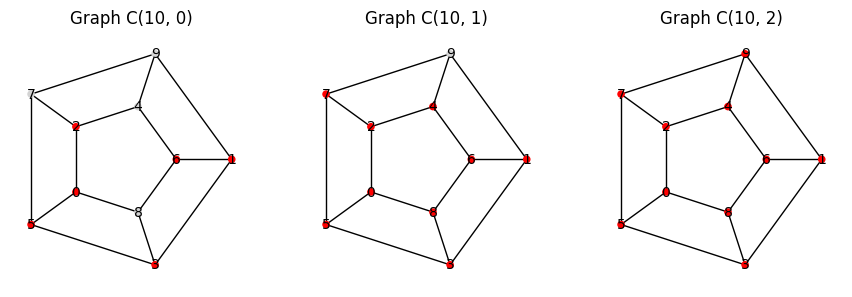


Fully endemic infection #69
Mask: [1, 1, 1, 1, 0, 1, 0, 1, 0, 0]
Steps to full infection: 2


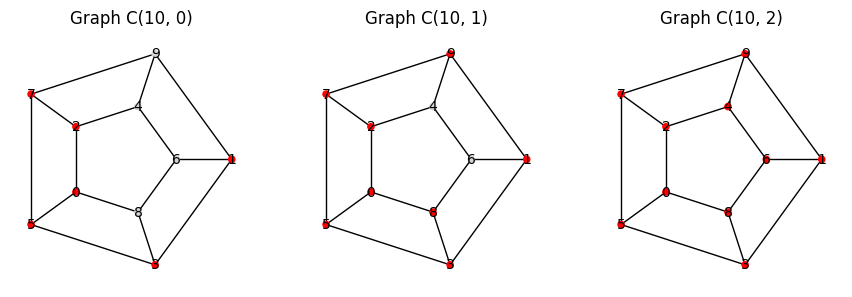


Fully endemic infection #70
Mask: [1, 1, 1, 1, 0, 1, 0, 0, 1, 0]
Steps to full infection: 2


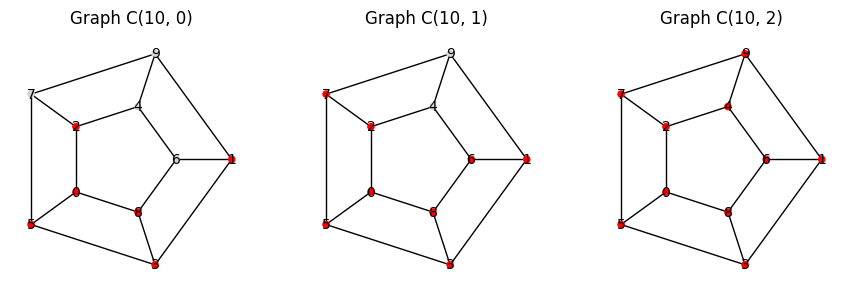


Fully endemic infection #71
Mask: [1, 1, 1, 1, 0, 1, 0, 0, 0, 1]
Steps to full infection: 2


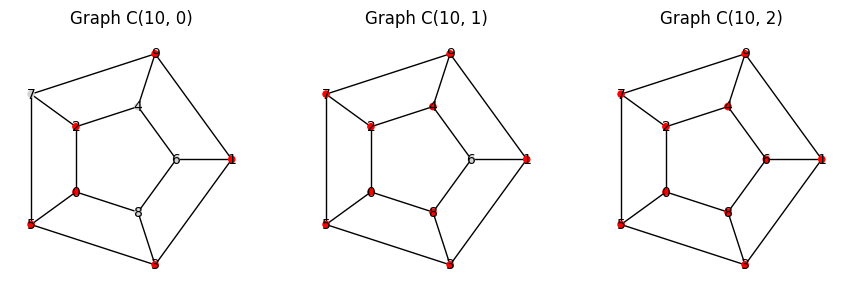


Fully endemic infection #72
Mask: [1, 1, 1, 1, 0, 0, 1, 1, 0, 0]
Steps to full infection: 1


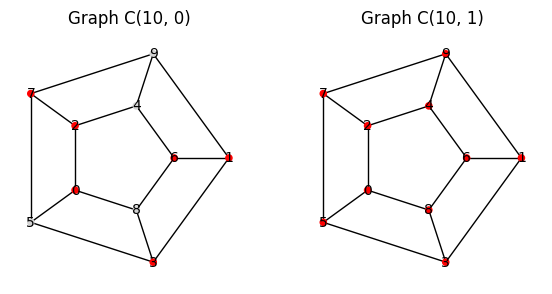


Fully endemic infection #73
Mask: [1, 1, 1, 1, 0, 0, 1, 0, 1, 0]
Steps to full infection: 2


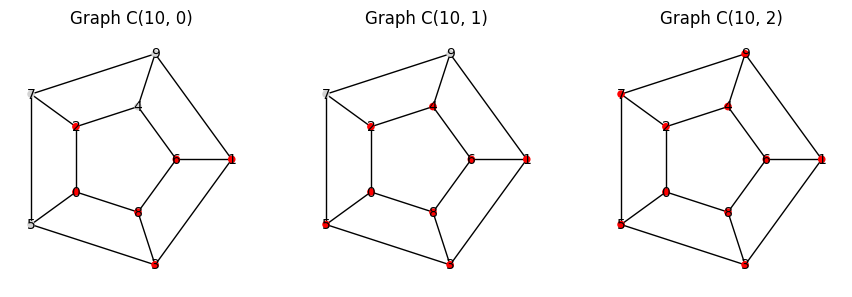


Fully endemic infection #74
Mask: [1, 1, 1, 1, 0, 0, 1, 0, 0, 1]
Steps to full infection: 1


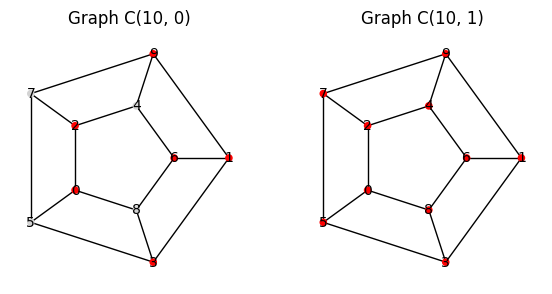


Fully endemic infection #75
Mask: [1, 1, 1, 1, 0, 0, 0, 1, 1, 0]
Steps to full infection: 2


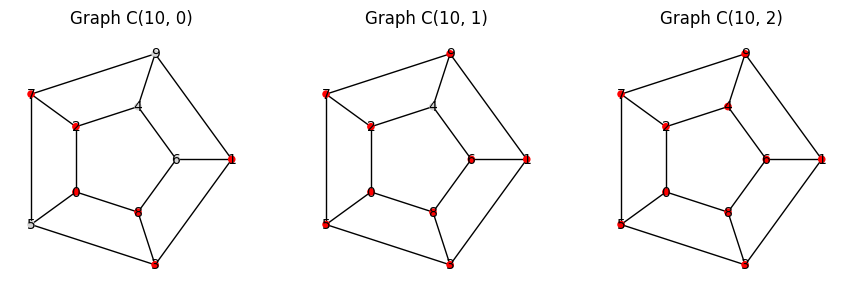


Fully endemic infection #76
Mask: [1, 1, 1, 1, 0, 0, 0, 1, 0, 1]
Steps to full infection: 2


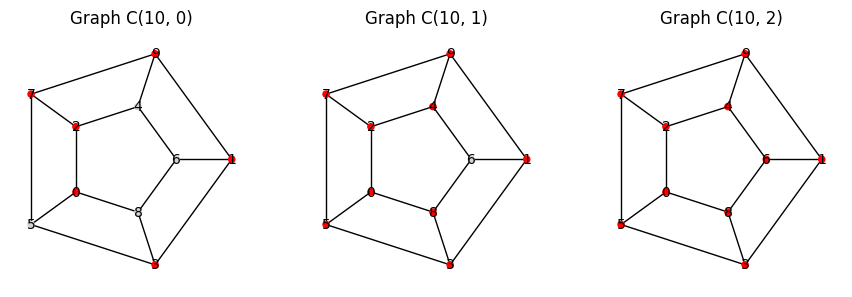


Fully endemic infection #77
Mask: [1, 1, 1, 1, 0, 0, 0, 0, 1, 1]
Steps to full infection: 1


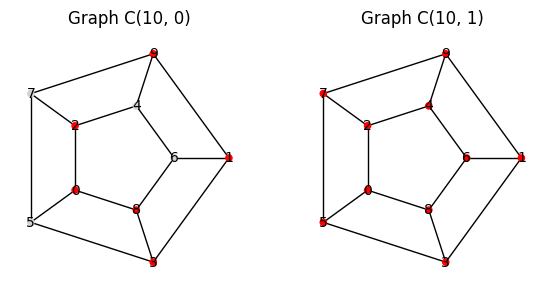


Fully endemic infection #78
Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
Steps to full infection: 1


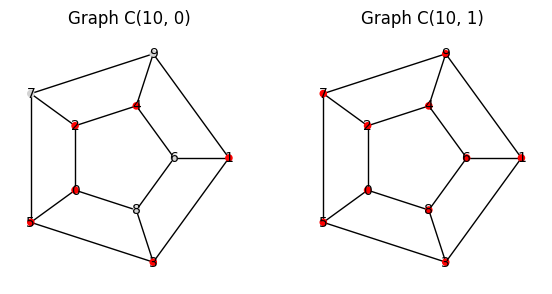


Fully endemic infection #79
Mask: [1, 1, 1, 1, 1, 0, 1, 0, 0, 0]
Steps to full infection: 2


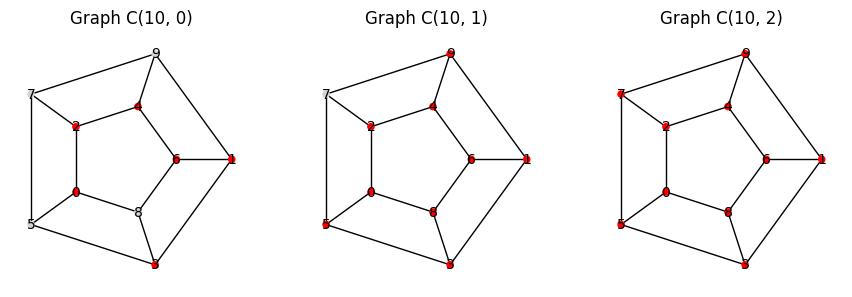


Fully endemic infection #80
Mask: [1, 1, 1, 1, 1, 0, 0, 1, 0, 0]
Steps to full infection: 1


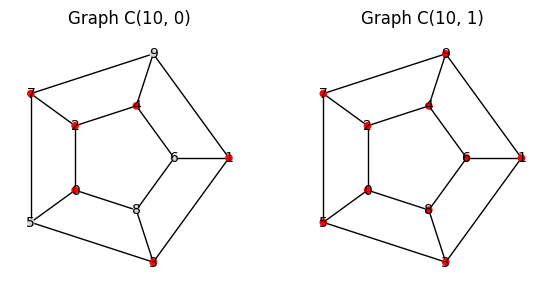


Fully endemic infection #81
Mask: [1, 1, 1, 1, 1, 0, 0, 0, 1, 0]
Steps to full infection: 2


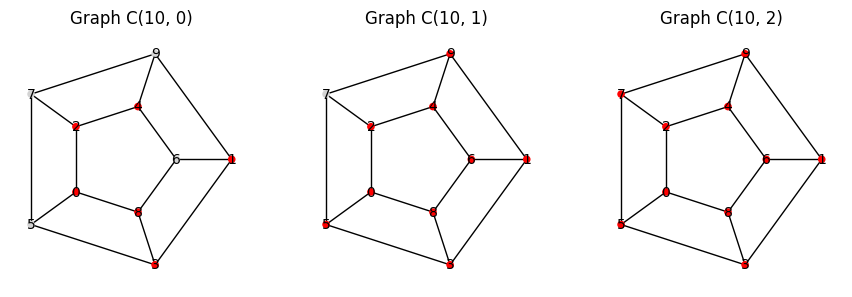


Fully endemic infection #82
Mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 1]
Steps to full infection: 1


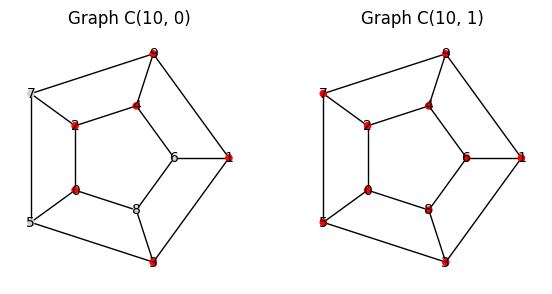


Fully endemic infection #83
Mask: [1, 1, 0, 0, 0, 1, 1, 1, 1, 1]
Steps to full infection: 1


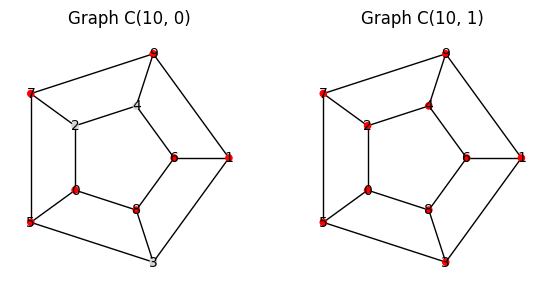


Fully endemic infection #84
Mask: [1, 1, 1, 0, 0, 1, 1, 1, 1, 0]
Steps to full infection: 1


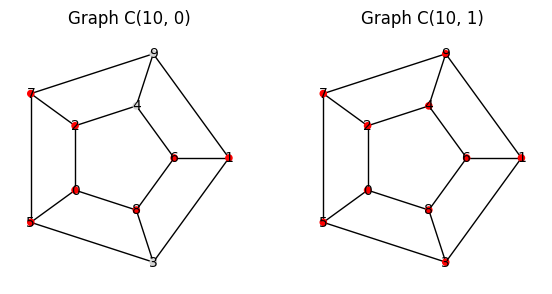


Fully endemic infection #85
Mask: [1, 1, 1, 0, 0, 1, 1, 1, 0, 1]
Steps to full infection: 1


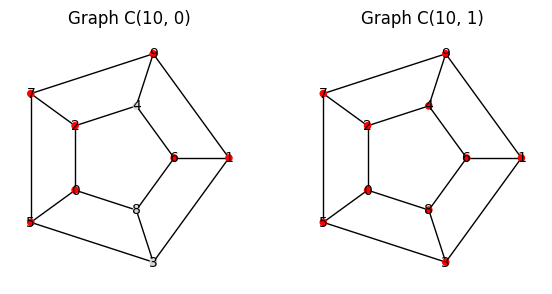


Fully endemic infection #86
Mask: [1, 1, 1, 0, 0, 1, 1, 0, 1, 1]
Steps to full infection: 1


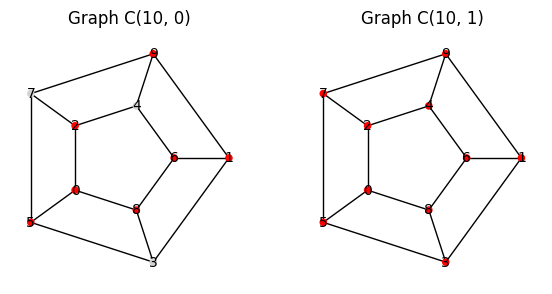


Fully endemic infection #87
Mask: [1, 1, 1, 0, 0, 1, 0, 1, 1, 1]
Steps to full infection: 1


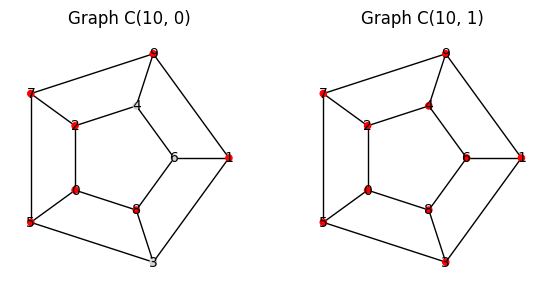


Fully endemic infection #88
Mask: [1, 1, 1, 0, 0, 0, 1, 1, 1, 1]
Steps to full infection: 1


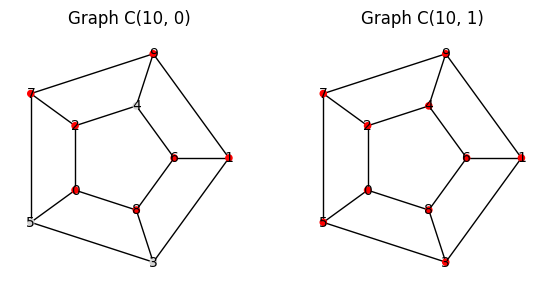


Fully endemic infection #89
Mask: [1, 1, 1, 1, 0, 1, 1, 1, 0, 0]
Steps to full infection: 1


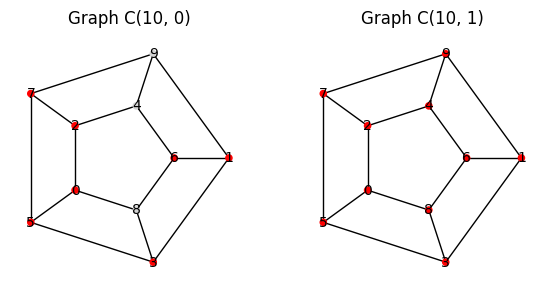


Fully endemic infection #90
Mask: [1, 1, 1, 1, 0, 1, 1, 0, 1, 0]
Steps to full infection: 2


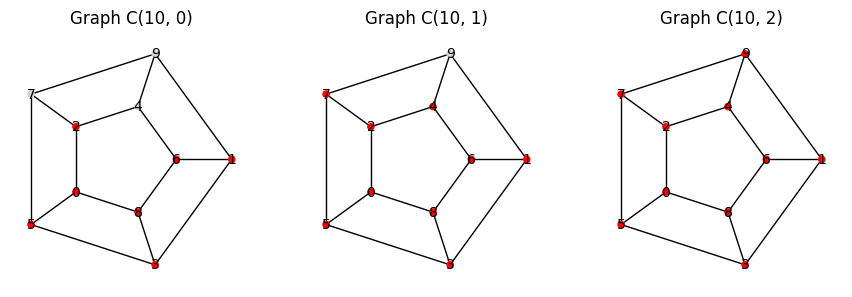


Fully endemic infection #91
Mask: [1, 1, 1, 1, 0, 1, 1, 0, 0, 1]
Steps to full infection: 1


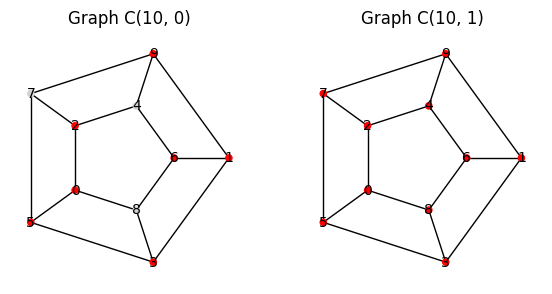


Fully endemic infection #92
Mask: [1, 1, 1, 1, 0, 1, 0, 1, 1, 0]
Steps to full infection: 2


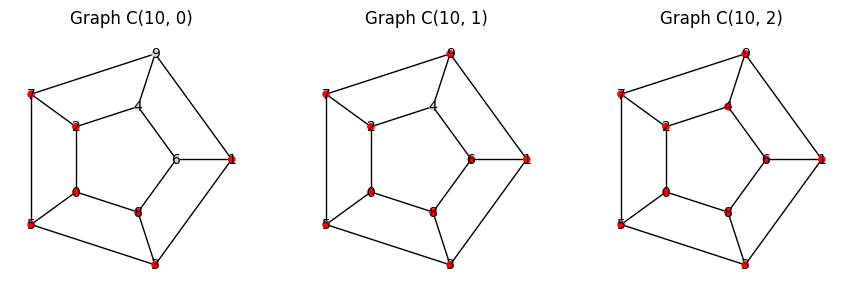


Fully endemic infection #93
Mask: [1, 1, 1, 1, 0, 1, 0, 1, 0, 1]
Steps to full infection: 2


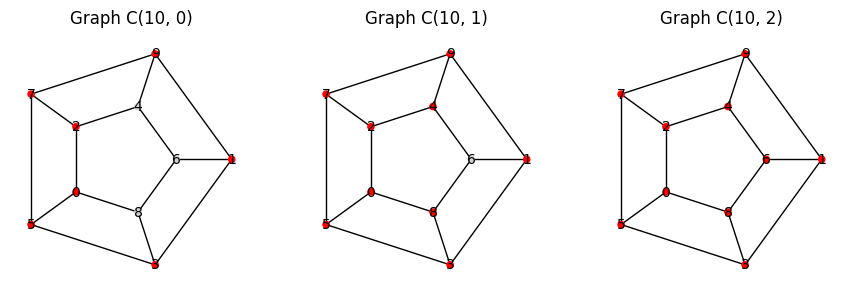


Fully endemic infection #94
Mask: [1, 1, 1, 1, 0, 1, 0, 0, 1, 1]
Steps to full infection: 1


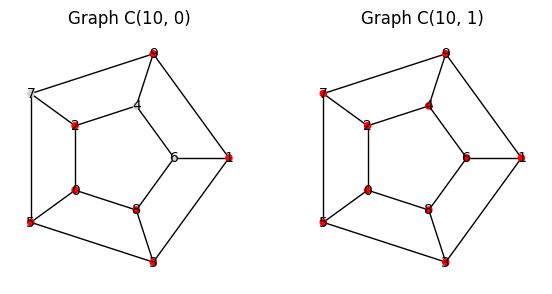


Fully endemic infection #95
Mask: [1, 1, 1, 1, 0, 0, 1, 1, 1, 0]
Steps to full infection: 1


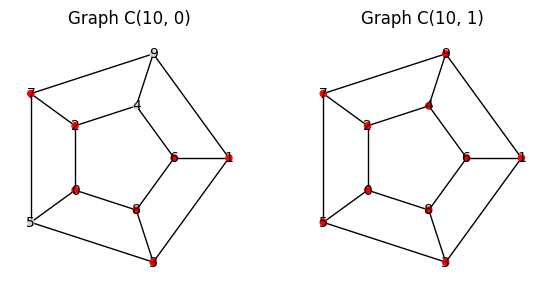


Fully endemic infection #96
Mask: [1, 1, 1, 1, 0, 0, 1, 1, 0, 1]
Steps to full infection: 1


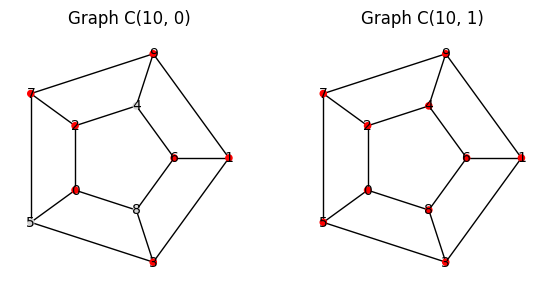


Fully endemic infection #97
Mask: [1, 1, 1, 1, 0, 0, 1, 0, 1, 1]
Steps to full infection: 1


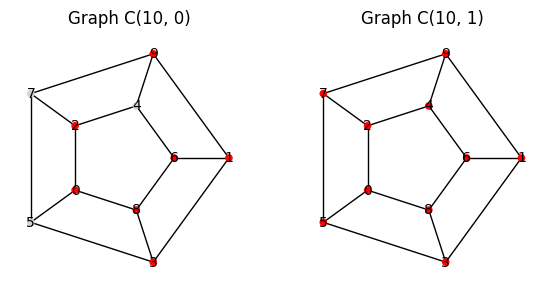


Fully endemic infection #98
Mask: [1, 1, 1, 1, 0, 0, 0, 1, 1, 1]
Steps to full infection: 1


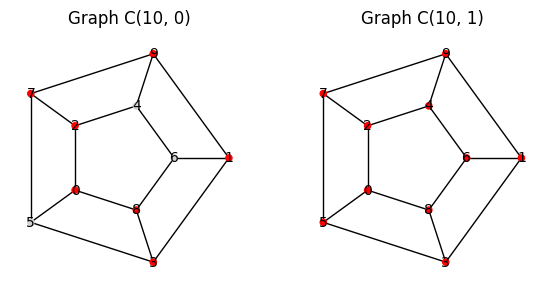


Fully endemic infection #99
Mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
Steps to full infection: 1


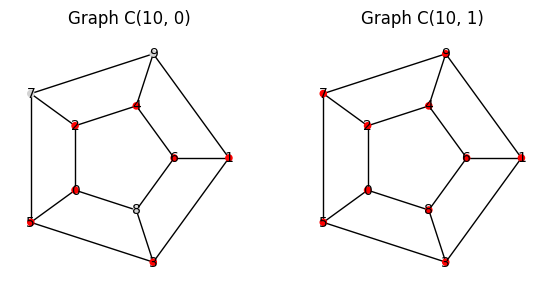


Fully endemic infection #100
Mask: [1, 1, 1, 1, 1, 1, 0, 1, 0, 0]
Steps to full infection: 1


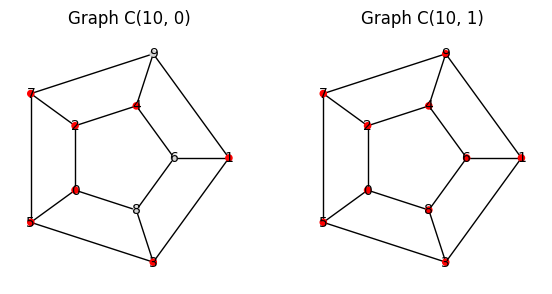


Fully endemic infection #101
Mask: [1, 1, 1, 1, 1, 1, 0, 0, 1, 0]
Steps to full infection: 1


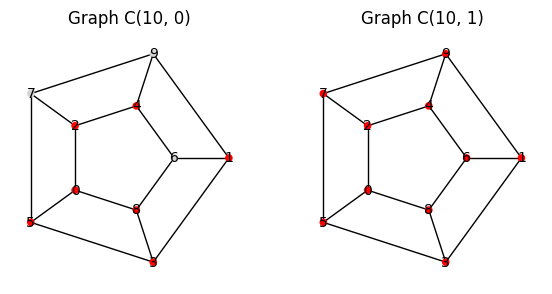


Fully endemic infection #102
Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 1]
Steps to full infection: 1


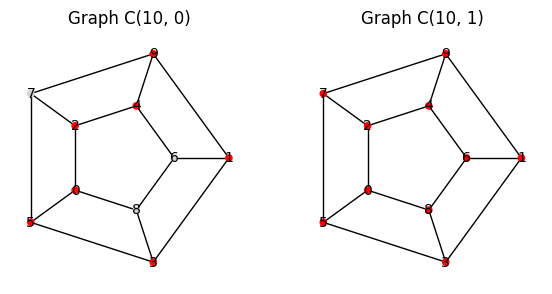


Fully endemic infection #103
Mask: [1, 1, 1, 1, 1, 0, 1, 1, 0, 0]
Steps to full infection: 1


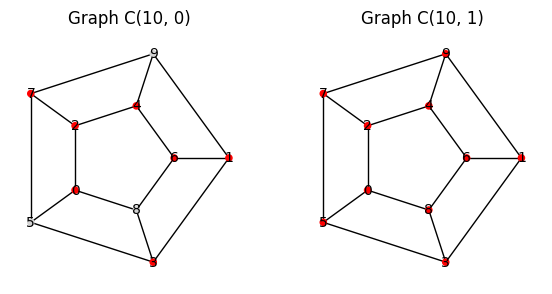


Fully endemic infection #104
Mask: [1, 1, 1, 1, 1, 0, 1, 0, 1, 0]
Steps to full infection: 2


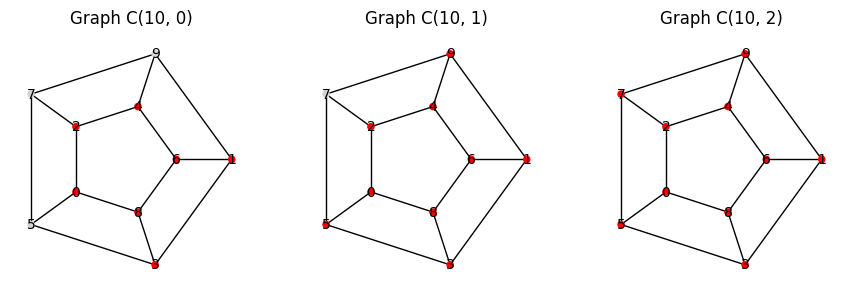


Fully endemic infection #105
Mask: [1, 1, 1, 1, 1, 0, 1, 0, 0, 1]
Steps to full infection: 1


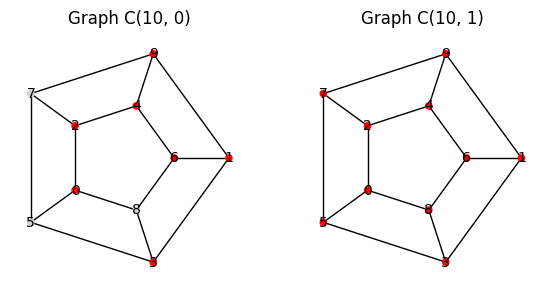


Fully endemic infection #106
Mask: [1, 1, 1, 1, 1, 0, 0, 1, 1, 0]
Steps to full infection: 1


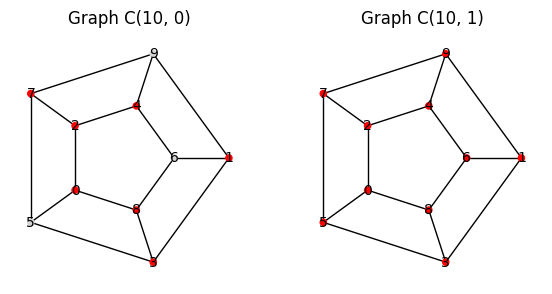


Fully endemic infection #107
Mask: [1, 1, 1, 1, 1, 0, 0, 1, 0, 1]
Steps to full infection: 1


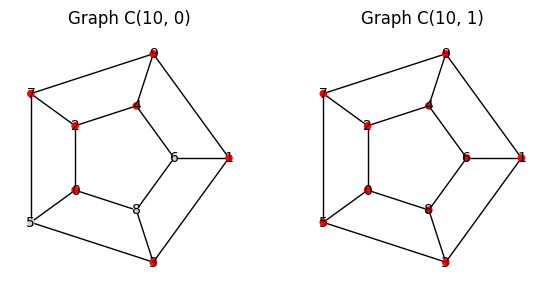


Fully endemic infection #108
Mask: [1, 1, 1, 1, 1, 0, 0, 0, 1, 1]
Steps to full infection: 1


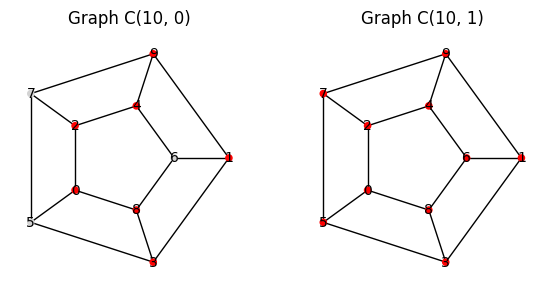


Fully endemic infection #109
Mask: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1]
Steps to full infection: 1


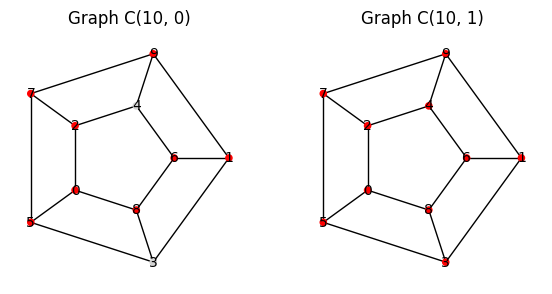


Fully endemic infection #110
Mask: [1, 1, 1, 1, 0, 1, 1, 1, 1, 0]
Steps to full infection: 1


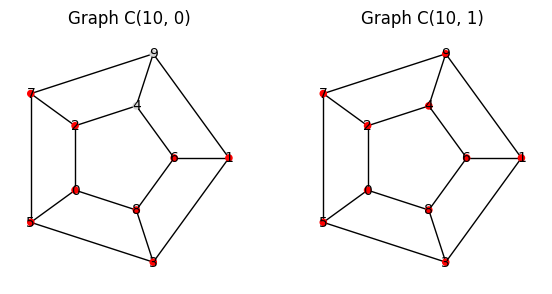


Fully endemic infection #111
Mask: [1, 1, 1, 1, 0, 1, 1, 1, 0, 1]
Steps to full infection: 1


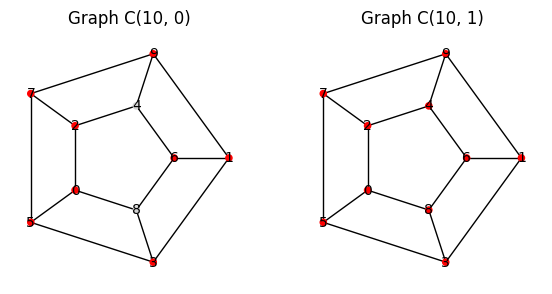


Fully endemic infection #112
Mask: [1, 1, 1, 1, 0, 1, 1, 0, 1, 1]
Steps to full infection: 1


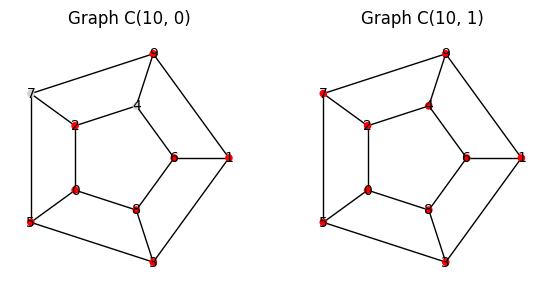


Fully endemic infection #113
Mask: [1, 1, 1, 1, 0, 1, 0, 1, 1, 1]
Steps to full infection: 1


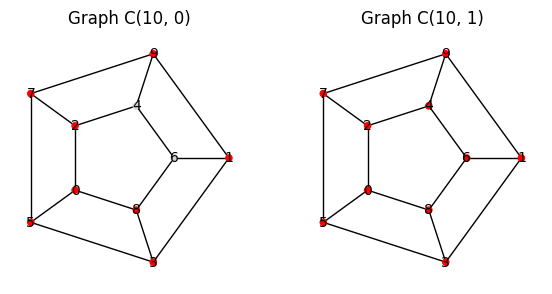


Fully endemic infection #114
Mask: [1, 1, 1, 1, 0, 0, 1, 1, 1, 1]
Steps to full infection: 1


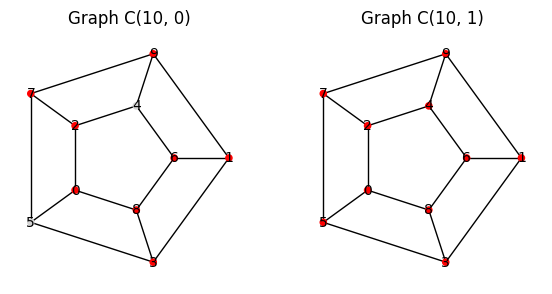


Fully endemic infection #115
Mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Steps to full infection: 1


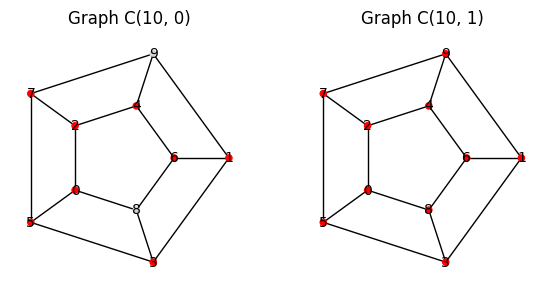


Fully endemic infection #116
Mask: [1, 1, 1, 1, 1, 1, 1, 0, 1, 0]
Steps to full infection: 1


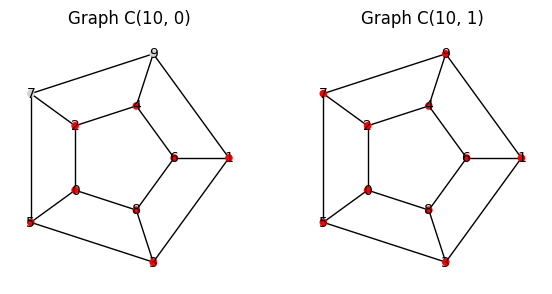


Fully endemic infection #117
Mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 1]
Steps to full infection: 1


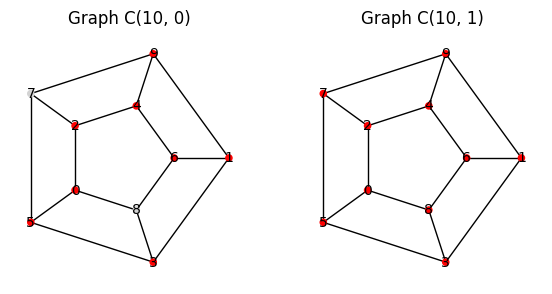


Fully endemic infection #118
Mask: [1, 1, 1, 1, 1, 1, 0, 1, 1, 0]
Steps to full infection: 1


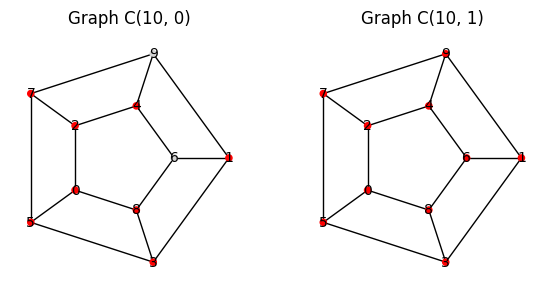


Fully endemic infection #119
Mask: [1, 1, 1, 1, 1, 1, 0, 1, 0, 1]
Steps to full infection: 1


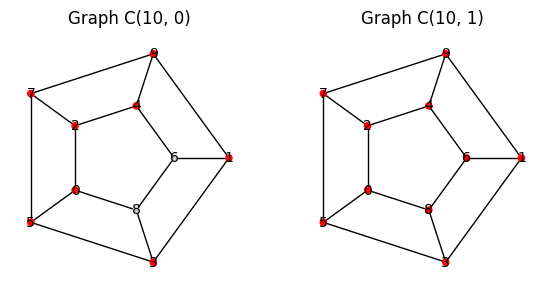


Fully endemic infection #120
Mask: [1, 1, 1, 1, 1, 1, 0, 0, 1, 1]
Steps to full infection: 1


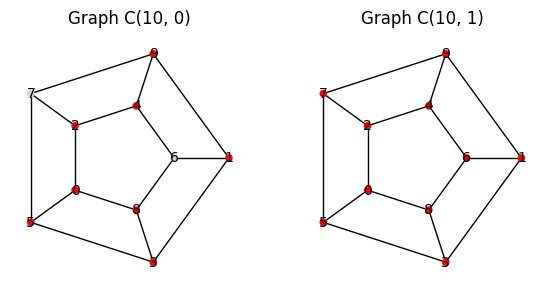


Fully endemic infection #121
Mask: [1, 1, 1, 1, 1, 0, 1, 1, 1, 0]
Steps to full infection: 1


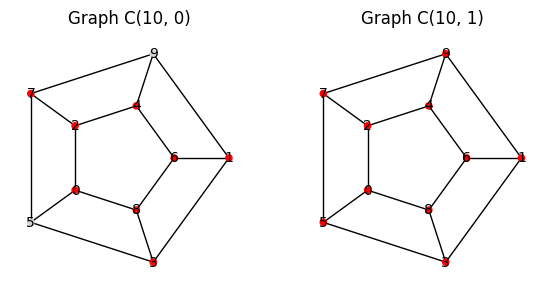


Fully endemic infection #122
Mask: [1, 1, 1, 1, 1, 0, 1, 1, 0, 1]
Steps to full infection: 1


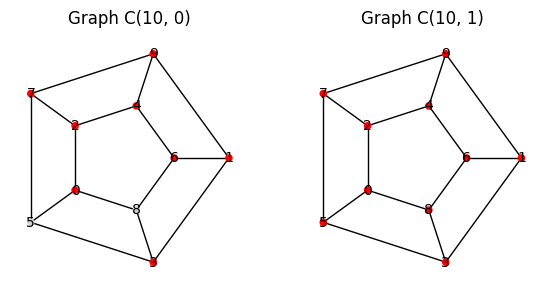


Fully endemic infection #123
Mask: [1, 1, 1, 1, 1, 0, 1, 0, 1, 1]
Steps to full infection: 1


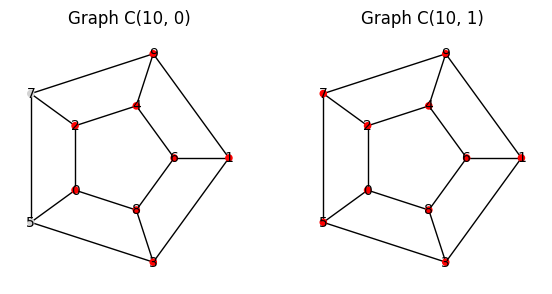


Fully endemic infection #124
Mask: [1, 1, 1, 1, 1, 0, 0, 1, 1, 1]
Steps to full infection: 1


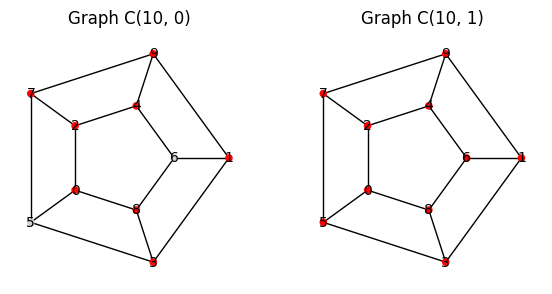


Fully endemic infection #125
Mask: [1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
Steps to full infection: 1


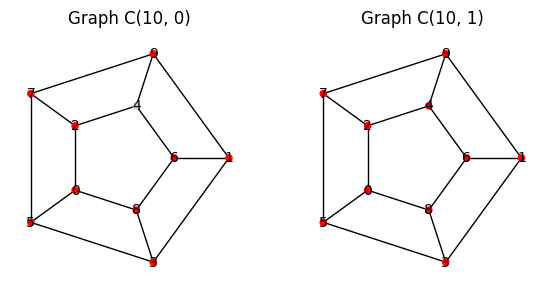


Fully endemic infection #126
Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
Steps to full infection: 1


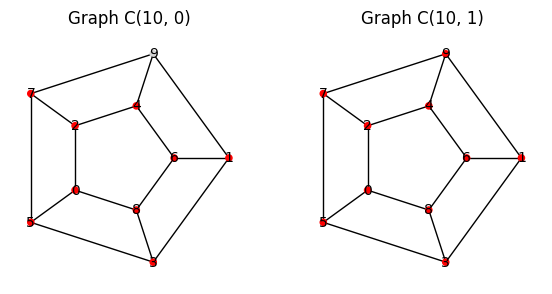


Fully endemic infection #127
Mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
Steps to full infection: 1


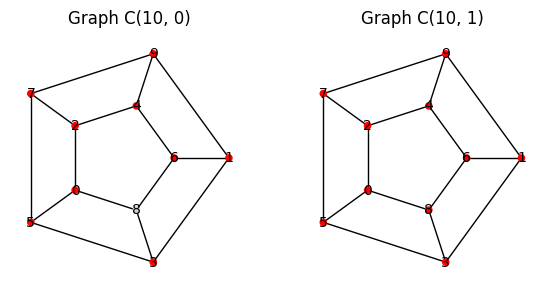


Fully endemic infection #128
Mask: [1, 1, 1, 1, 1, 1, 1, 0, 1, 1]
Steps to full infection: 1


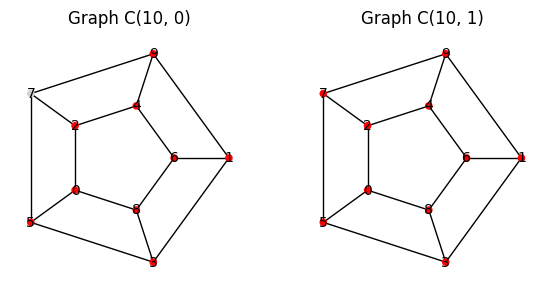


Fully endemic infection #129
Mask: [1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
Steps to full infection: 1


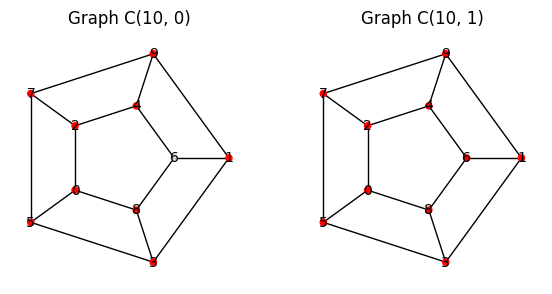


Fully endemic infection #130
Mask: [1, 1, 1, 1, 1, 0, 1, 1, 1, 1]
Steps to full infection: 1


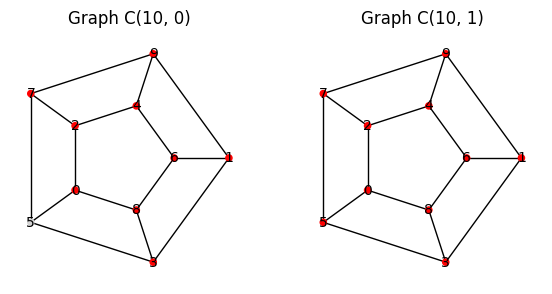

In [7]:
def find_fully_endemic_infections(G, infection_masks):
    endemic_results = []

    for mask in infection_masks:
        # infect graph
        G0 = infect_graph(G, mask)

        # run spread
        stages, infected_nodes, healthy_nodes = infection_spread(G0)

        # fully endemic if nobody remains healthy
        if not healthy_nodes:
            endemic_results.append({
                "mask": mask,
                "stages": stages,
                "steps": len(stages) - 1
            })

    return endemic_results


def display_infection_animation(stages, pos=None):
    graphs = []

    for i, H in enumerate(stages):
        graphs.append((H, len(H.nodes), i))

    display_graphs(
        graphs,
        figsize=(3 * len(graphs), 3),
        show_titles=True,
        force_row=True,
        with_labels=True,
        pos=pos
    )


infection_masks = list(generate_infection_prism2(G))
endemic = find_fully_endemic_infections(G, infection_masks)
print("Number of fully endemic infections:", len(endemic))

for i, result in enumerate(endemic):
    print(f"\nFully endemic infection #{i+1}")
    print("Mask:", result["mask"])
    print("Steps to full infection:", result["steps"])

    display_infection_animation(
        result["stages"],
        pos=lambda H: prism_pos(H)
    )
